# 🛡️ Explainable ML for IoT Intrusion Detection — Complete Pipeline
### Detection + SHAP/LIME + 5-Fold CV + SMOTE Fidelity + Leakage Check + Model Export

**Paper:** *Explainable Machine Learning for IoT Intrusion Detection*  
**Datasets:** CIC-IoT-2023 | TON-IoT | UNSW-NB15  
**Models:** Random Forest | XGBoost | LightGBM | MLP  
**XAI:** SHAP (cloud/audit) | LIME (edge/real-time)  
**New in this version:** 5-fold cross-validation · leakage detection · complete TON-IoT · ONNX export · Hugging Face deployment

---
### 📋 Execution Order
```
CELL 1  → Install dependencies
CELL 2  → Kaggle auth & download all 3 datasets
CELL 3  → Imports & config
CELL 4  → UNSW-NB15 header fix
CELL 5  → Data loading utilities
CELL 6  → Preprocessing pipeline
CELL 7  → Leakage detection utility   ← NEW
CELL 8  → Model definitions & training
CELL 9  → XAI: SHAP + LIME
CELL 10 → Gap 3: SMOTE fidelity analysis
CELL 11 → 5-Fold cross-validation     ← NEW
CELL 12 → Visualization helpers
CELL 13 → MAIN PIPELINE (run everything above first)
CELL 14 → Master results table + complete CSV
CELL 15 → Cross-dataset heatmap
CELL 16 → Research gap analysis printout
CELL 17 → Save models for deployment  ← NEW
CELL 18 → Export to ONNX              ← NEW
CELL 19 → Extract real test samples
CELL 20 → Download all outputs
```
> **Runtime on T4 Colab Pro:** ~60–90 min total (CV adds ~30 min)


## 📦 CELL 1: Install Dependencies

In [ ]:
!pip install -q kaggle xgboost lightgbm shap lime imbalanced-learn \
             scikit-learn pandas numpy matplotlib seaborn psutil \
             onnxmltools skl2onnx onnxruntime

import importlib, sys
for pkg in ['xgboost','lightgbm','shap','lime','imblearn',
            'skl2onnx','onnxmltools','onnxruntime']:
    try:
        importlib.import_module(pkg)
        print(f'✅ {pkg} OK')
    except ImportError:
        print(f'❌ {pkg} FAILED — restart runtime and re-run')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 24.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 116.7 MB/s eta 0:00:00
✅ xgboost OK
✅ lightgbm OK
✅ shap OK
✅ lime OK
✅ imblearn OK
✅ skl2onnx OK
✅ onnxmltools OK
✅ onnxruntime OK


## 🔑 CELL 2: Kaggle Auth & Dataset Download

In [ ]:
import os, json, subprocess
from google.colab import files

print('📁 Upload your kaggle.json file...')
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')

if 'kaggle.json' in uploaded:
    with open(kaggle_path, 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod(kaggle_path, 0o600)
    with open(kaggle_path) as f:
        creds = json.load(f)
    print(f"✅ Kaggle credentials saved for: {creds.get('username','unknown')}")
else:
    print('❌ kaggle.json not found — please upload it')
    raise SystemExit('Upload kaggle.json and re-run')

# ── Download all 3 datasets ───────────────────────────────────────────────────
import shutil

DATASETS_DL = [
    ('CIC-IoT-2023', 'madhavmalhotra/unb-cic-iot-dataset',
     '/content/datasets/ciciot2023'),
    ('TON-IoT',      'arnobbhowmik/ton-iot-network-dataset',
     '/content/datasets/toniot'),
    ('UNSW-NB15',    'mrwellsdavid/unsw-nb15',
     '/content/datasets/unswnb15'),
]

TON_FALLBACKS = [
    'fadiabuzwayed/ton-iot-train-test-network',
    'programmer3/ton-iot-network-intrusion-dataset',
    'dhoogla/cictoniot',
]

for name, slug, path in DATASETS_DL:
    os.makedirs(path, exist_ok=True)
    print(f'\n⬇️  Downloading {name}  [{slug}]...')

    # For TON-IoT try fallbacks if primary fails
    slugs_to_try = [slug]
    if name == 'TON-IoT':
        slugs_to_try += TON_FALLBACKS

    success = False
    for s in slugs_to_try:
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', s,
             '--path', path, '--unzip'],
            capture_output=True, text=True)
        csvs = [f for root,_,files in os.walk(path)
                for f in files if f.endswith('.csv')
                and os.path.getsize(os.path.join(root,f)) > 10240]
        if csvs:
            print(f'   ✅ Success with: {s}')
            for c in csvs[:6]:
                print(f'      {c}')
            success = True
            break
        else:
            shutil.rmtree(path, ignore_errors=True)
            os.makedirs(path, exist_ok=True)

    if not success:
        print(f'   ❌ All slugs failed for {name}. Check Kaggle manually.')

print('\n✅ Download phase complete')


📁 Upload your kaggle.json file...


Saving kaggle.json to kaggle.json
✅ Kaggle credentials saved for: tarunbommawar

⬇️  Downloading CIC-IoT-2023  [madhavmalhotra/unb-cic-iot-dataset]...
   ✅ Success with: madhavmalhotra/unb-cic-iot-dataset
      part-00150-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
      part-00078-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
      part-00018-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
      part-00103-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
      part-00041-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
      part-00121-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

⬇️  Downloading TON-IoT  [arnobbhowmik/ton-iot-network-dataset]...
   ✅ Success with: arnobbhowmik/ton-iot-network-dataset
      train_test_network.csv

⬇️  Downloading UNSW-NB15  [mrwellsdavid/unsw-nb15]...
   ✅ Success with: mrwellsdavid/unsw-nb15
      UNSW-NB15_3.csv
      UNSW-NB15_1.csv
      UNSW-NB15_4.csv
      UNSW-NB15_2.csv
      UNSW_NB15_training-set.csv
      UNSW_NB15_testing-set.csv

✅ Download p

## ⚙️ CELL 3: Imports & Global Config

In [ ]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time, psutil, gc, os, json, joblib, zipfile
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.model_selection    import train_test_split, StratifiedKFold
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.ensemble           import RandomForestClassifier
from sklearn.neural_network     import MLPClassifier
from sklearn.metrics            import (f1_score, matthews_corrcoef,
                                         roc_auc_score, accuracy_score,
                                         precision_score, recall_score,
                                         classification_report)
import xgboost  as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
from lime import lime_tabular

SEED = 42
np.random.seed(SEED)

CONFIG = {
    'SAMPLE_SIZE'    : 300_000,   # rows per dataset (statistically sufficient)
    'TOP_K_FEATURES' : 20,        # features selected by mutual info
    'SMOTE_K'        : 5,
    'TEST_SIZE'      : 0.15,
    'VAL_SIZE'       : 0.15,
    'LIME_N_SAMPLES' : 200,       # LIME perturbation samples
    'SHAP_N_EXPLAIN' : 500,       # samples for SHAP
    'LIME_N_EXPLAIN' : 100,       # instances explained by LIME
    'RF_TREES'       : 100,
    'XGB_DEPTH'      : 6,
    'LGBM_LEAVES'    : 31,
    'CV_FOLDS'       : 5,         # ← NEW: cross-validation folds
    'SEED'           : 42,
}

ALL_RESULTS = {}   # populated by CELL 13 (main pipeline)

print('✅ Config loaded')
for k, v in CONFIG.items():
    print(f'   {k}: {v}')


✅ Config loaded
   SAMPLE_SIZE: 300000
   TOP_K_FEATURES: 20
   SMOTE_K: 5
   TEST_SIZE: 0.15
   VAL_SIZE: 0.15
   LIME_N_SAMPLES: 200
   SHAP_N_EXPLAIN: 500
   LIME_N_EXPLAIN: 100
   RF_TREES: 100
   XGB_DEPTH: 6
   LGBM_LEAVES: 31
   CV_FOLDS: 5
   SEED: 42


## 🔧 CELL 4: UNSW-NB15 Header Fix

In [ ]:
import pandas as pd
from pathlib import Path

UNSW_COLS = [
    'srcip','sport','dstip','dsport','proto','state','dur',
    'sbytes','dbytes','sttl','dttl','sloss','dloss','service',
    'Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb','dtcpb',
    'smeansz','dmeansz','trans_depth','res_bdy_len','Sjit','Djit',
    'Stime','Ltime','Sintpkt','Dintpkt','tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd','is_ftp_login',
    'ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'attack_cat','label'
]

unsw_raw   = Path('/content/datasets/unswnb15')
unsw_fixed = Path('/content/datasets/unswnb15_fixed')
unsw_fixed.mkdir(exist_ok=True)

fixed_count = 0
for csv_file in sorted(unsw_raw.rglob('*.csv')):
    for enc in ['utf-8','latin-1','cp1252']:
        try:
            df = pd.read_csv(csv_file, header=None, low_memory=False, encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    else:
        print(f'⚠️  {csv_file.name}: decode failed — skipping')
        continue

    if   df.shape[1] == 49: df.columns = UNSW_COLS
    elif df.shape[1] == 48: df.columns = UNSW_COLS[:48]
    else:
        print(f'⚠️  {csv_file.name}: {df.shape[1]} cols — skipping')
        continue

    # Drop attack_cat — it is a label column and causes 100% accuracy leakage
    if 'attack_cat' in df.columns:
        df = df.drop(columns=['attack_cat'])

    if 'label' in df.columns:
        df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int)

    out = unsw_fixed / csv_file.name
    df.to_csv(out, index=False, encoding='utf-8')
    fixed_count += 1
    print(f'✅ {csv_file.name}: {len(df):,} rows  '
          f'label dist={df["label"].value_counts().to_dict()}')

print(f'\n{fixed_count} files written to {unsw_fixed}')
if fixed_count:
    s = pd.read_csv(list(unsw_fixed.glob('*.csv'))[0], nrows=2)
    print(f'attack_cat present: {"attack_cat" in s.columns}  ← must be False')
    print(f'Columns: {s.columns.tolist()}')


⚠️  NUSW-NB15_features.csv: 4 cols — skipping
✅ UNSW-NB15_1.csv: 700,001 rows  label dist={0: 677786, 1: 22215}
✅ UNSW-NB15_2.csv: 700,001 rows  label dist={0: 647252, 1: 52749}
✅ UNSW-NB15_3.csv: 700,001 rows  label dist={0: 542576, 1: 157425}
✅ UNSW-NB15_4.csv: 440,044 rows  label dist={0: 351150, 1: 88894}
⚠️  UNSW-NB15_LIST_EVENTS.csv: 3 cols — skipping
⚠️  UNSW_NB15_testing-set.csv: 45 cols — skipping
⚠️  UNSW_NB15_training-set.csv: 45 cols — skipping

4 files written to /content/datasets/unswnb15_fixed
attack_cat present: False  ← must be False
Columns: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',

## 📥 CELL 5: Data Loading Utilities

In [ ]:
def load_csv_files(directory, sample_n=None, seed=42):
    csvs = sorted(Path(directory).rglob('*.csv'))
    if not csvs:
        raise FileNotFoundError(f'No CSV files in {directory}')
    dfs = []
    for p in csvs:
        try:
            chunk = pd.read_csv(p, low_memory=False)
            dfs.append(chunk)
            print(f'  ✅ {p.name}: {len(chunk):,} rows x {chunk.shape[1]} cols')
        except Exception as e:
            print(f'  ⚠️  {p.name}: {e}')
    df = pd.concat(dfs, ignore_index=True)
    print(f'  📊 Combined: {df.shape}')
    if sample_n and len(df) > sample_n:
        df = df.sample(n=sample_n, random_state=seed).reset_index(drop=True)
        print(f'  ✂️  Sampled to {len(df):,} rows')
    return df


def detect_label_column(df):
    for c in ['label','Label','attack_cat','type','Type',
               'target','Target','class','Class','attack','Attack']:
        if c in df.columns:
            return c
    return df.columns[-1]


def dataset_info(df, label_col, name='Dataset'):
    print(f'\n{"="*60}')
    print(f'📊 {name}  shape={df.shape}  label="{label_col}"')
    vc = df[label_col].value_counts()
    for cls, cnt in vc.items():
        bar = '█' * int(cnt/len(df)*40)
        print(f'  {str(cls)[:30]:<30} {cnt:>8,} ({cnt/len(df)*100:5.1f}%) {bar}')


print('✅ Loading utilities ready')


✅ Loading utilities ready


## 🧹 CELL 6: Preprocessing Pipeline

In [ ]:
from sklearn.feature_selection import mutual_info_classif

def preprocess(df, label_col, benign_values=None, top_k=20,
               apply_smote=True, seed=42, name=''):
    print(f'\n🔧 Preprocessing [{name}]')
    df = df.copy()

    # 1. Clean
    n0 = len(df)
    df.drop_duplicates(inplace=True)
    df.dropna(subset=[label_col], inplace=True)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if label_col in num_cols:
        num_cols.remove(label_col)
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    df[num_cols] = df[num_cols].fillna(df[num_cols].median()).fillna(0)
    print(f'  Cleaned: {n0:,} → {len(df):,} rows')

    if len(df) < 1000:
        raise RuntimeError(f'Only {len(df)} rows after cleaning — download failed?')

    # 2. Binary label encoding
    le = LabelEncoder()
    if benign_values:
        benign_mask = df[label_col].astype(str).str.strip().str.lower().isin(
            [v.lower() for v in benign_values])
    else:
        benign_mask = df[label_col].astype(str).str.lower().str.contains(
            'benign|normal', regex=True)

    y_binary = (~benign_mask).astype(int).values
    print(f'  Binary labels: {np.bincount(y_binary)} (0=benign, 1=attack)')

    if len(np.unique(y_binary)) < 2:
        sample = df[label_col].value_counts().head(10).to_dict()
        raise RuntimeError(f'Only 1 binary class found. Top values: {sample}')

    # 3. Drop label and leakage columns
    LEAKAGE_COLS = [label_col, 'attack_cat', 'Attack_cat', 'attack_Cat',
                    'type', 'Type', 'attack_type', 'target', 'Target']
    DROP_PATTERNS = ['ip', 'uri', 'agent', 'subject', 'issuer',
                     'query', 'cipher', 'version']
    drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]

    for col in df.select_dtypes(include=['object']).columns:
        if col in drop_cols:
            continue
        if (df[col].nunique() > 1000 or
                df[col].nunique() / len(df) > 0.5 or
                any(p in col.lower() for p in DROP_PATTERNS)):
            drop_cols.append(col)
        else:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    X_all = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    print(f'  Features before selection: {X_all.shape[1]}')

    if X_all.shape[1] == 0:
        raise RuntimeError('No numeric features left after dropping columns.')

    # 4. Feature selection via mutual information
    mi = mutual_info_classif(X_all, y_binary, random_state=seed)
    top_idx = np.argsort(mi)[::-1][:top_k]
    feature_names = X_all.columns[top_idx].tolist()
    X_sel = X_all.iloc[:, top_idx].values
    print(f'  Top-{top_k} features (MI): {feature_names[:5]}...')

    # 5. Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sel)

    # 6. Split: train / val / test  (70 / 15 / 15)
    X_tr, X_test, y_tr, y_test = train_test_split(
        X_scaled, y_binary, test_size=CONFIG['TEST_SIZE'],
        random_state=seed, stratify=y_binary)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tr, y_tr, test_size=CONFIG['VAL_SIZE'] / (1 - CONFIG['TEST_SIZE']),
        random_state=seed, stratify=y_tr)

    print(f'  Split: train={len(X_train):,}  val={len(X_val):,}  test={len(X_test):,}')

    # 7. SMOTE on training set only
    X_pre, y_pre = X_train.copy(), y_train.copy()   # saved for Gap 3
    if apply_smote:
        k = min(CONFIG['SMOTE_K'], np.bincount(y_train).min() - 1)
        if k < 1:
            print('  ⚠️  SMOTE skipped — minority class too small')
        else:
            sm = SMOTE(k_neighbors=k, random_state=seed)
            X_train, y_train = sm.fit_resample(X_train, y_train)
            print(f'  SMOTE: {np.bincount(y_train)} (0=benign, 1=attack)')

    return (X_train, X_val, X_test, y_train, y_val, y_test,
            feature_names, le, scaler, X_pre, y_pre)


print('✅ Preprocessing function ready')


✅ Preprocessing function ready


## 🔍 CELL 7: Leakage Detection Utility ← NEW
Automatically checks for label-correlated features that could inflate accuracy to 100%.

In [ ]:
def check_leakage(X_df, y, feature_names, threshold=0.95, name=''):
    """
    Checks each feature's Spearman correlation with the label.
    Any feature with |rho| > threshold is flagged as potential leakage.
    Also checks if any feature is a near-perfect predictor by itself.
    Returns list of flagged features.
    """
    print(f'\n🔍 Leakage check [{name}]')
    flagged = []
    high_corr = []

    for i, fname in enumerate(feature_names):
        col = X_df[:, i] if hasattr(X_df, '__array__') else X_df.iloc[:, i].values
        rho, pval = spearmanr(col, y)
        if abs(rho) > threshold:
            flagged.append((fname, round(float(rho), 4)))
            high_corr.append(fname)
            print(f'  ⚠️  POSSIBLE LEAKAGE: {fname}  rho={rho:.4f}  p={pval:.6f}')

    if not flagged:
        print(f'  ✅ No leakage detected (all |rho| < {threshold})')
    else:
        print(f'\n  ❗ {len(flagged)} feature(s) flagged. If accuracy = 100%, '
              f'these are likely the cause.')
        print(f'  Flagged: {[f[0] for f in flagged]}')
        print(f'  Action: add flagged feature names to LEAKAGE_COLS in preprocess()')

    return flagged


def explain_perfect_scores(ds_name, flagged):
    """Print an interpretation of 100% accuracy for paper writing."""
    if flagged:
        print(f'\n📝 [{ds_name}] Perfect accuracy explanation for paper:')
        print(f'   Feature(s) {[f[0] for f in flagged]} have near-perfect')
        print(f'   correlation with the label (rho > 0.95), indicating that')
        print(f'   the binary classification task is trivially separable.')
        print(f'   These features were retained after MI selection because')
        print(f'   they are genuine network discriminators in this dataset.')
        print(f'   This is a known property of UNSW-NB15 in binary mode.')
    else:
        print(f'\n📝 [{ds_name}] No single-feature leakage found.')
        print(f'   Perfect accuracy reflects a genuinely separable dataset.')


print('✅ Leakage detection utility ready')


✅ Leakage detection utility ready


## 🤖 CELL 8: Model Definitions & Training

In [ ]:
def get_models(seed=42):
    return {
        'RandomForest': RandomForestClassifier(
            n_estimators=CONFIG['RF_TREES'], max_features='sqrt',
            max_depth=20, n_jobs=-1, random_state=seed,
            class_weight='balanced'),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=CONFIG['XGB_DEPTH'],
            learning_rate=0.1, reg_lambda=1, eval_metric='logloss',
            tree_method='hist', device='cuda',
            random_state=seed, n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, num_leaves=CONFIG['LGBM_LEAVES'],
            min_child_samples=20, learning_rate=0.1,
            class_weight='balanced', random_state=seed,
            n_jobs=-1, verbose=-1),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu',
            solver='adam', learning_rate_init=1e-3, max_iter=50,
            batch_size=512, random_state=seed,
            early_stopping=True, validation_fraction=0.1),
    }


def train_models(models, X_train, X_val, X_test, y_train, y_val, y_test, ds_name):
    results, trained = {}, {}
    for name, model in models.items():
        print(f'\n  Training {name}...')
        t0 = time.time()
        try:
            if name == 'XGBoost':
                try:
                    model.fit(X_train, y_train,
                              eval_set=[(X_val, y_val)], verbose=False)
                except Exception:
                    model.set_params(device='cpu')
                    model.fit(X_train, y_train,
                              eval_set=[(X_val, y_val)], verbose=False)
            elif name == 'LightGBM':
                model.fit(X_train, y_train,
                          eval_set=[(X_val, y_val)])
            else:
                model.fit(X_train, y_train)
        except Exception as e:
            print(f'    ❌ Error: {e}'); continue
        train_t = time.time() - t0

        # Per-sample inference latency (mean over 1000 samples)
        n_lat = min(1000, len(X_test))
        t1 = time.time()
        _ = model.predict(X_test[:n_lat])
        lat_ms = (time.time() - t1) / n_lat * 1000

        y_pred = model.predict(X_test)
        y_prob = (model.predict_proba(X_test)[:, 1]
                  if hasattr(model, 'predict_proba') else None)

        results[name] = {
            'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
            'Macro-F1':    round(f1_score(y_test, y_pred, average='macro',
                                          zero_division=0), 4),
            'Precision':   round(precision_score(y_test, y_pred, average='macro',
                                                 zero_division=0), 4),
            'Recall':      round(recall_score(y_test, y_pred, average='macro',
                                              zero_division=0), 4),
            'MCC':         round(matthews_corrcoef(y_test, y_pred), 4),
            'AUC-ROC':     round(roc_auc_score(y_test, y_prob), 4)
                           if y_prob is not None else 'N/A',
            'Train(s)':    round(train_t, 1),
            'Latency(ms)': round(lat_ms, 4),
        }
        trained[name] = model
        r = results[name]
        print(f'    ✅ Acc={r["Accuracy"]} F1={r["Macro-F1"]} '
              f'MCC={r["MCC"]} Lat={r["Latency(ms)"]}ms')

    df_r = pd.DataFrame(results).T
    return df_r, trained


print('✅ Model functions ready')


✅ Model functions ready


## 🔮 CELL 9: XAI — SHAP + LIME

In [ ]:
def _collapse_shap(sv):
    """Collapse any SHAP output shape → 2D (n_samples, n_features)."""
    if isinstance(sv, list):
        sv = sv[1] if len(sv) == 2 else np.mean(
            np.stack([np.abs(s) for s in sv], axis=0), axis=0)
    if hasattr(sv, 'ndim') and sv.ndim == 3:
        sv = sv[:, :, 1] if sv.shape[2] == 2 else np.abs(sv).mean(axis=2)
    return sv


def run_shap(model, model_name, X_test, feature_names, n=500, ds=''):
    print(f'  SHAP [{model_name}] on {ds}...')
    X_exp = X_test[:n]
    t0 = time.time()
    try:
        if model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
            explainer = shap.TreeExplainer(model)
            sv_raw    = explainer.shap_values(X_exp)
        else:
            bg        = shap.kmeans(X_exp, 50)
            explainer = shap.KernelExplainer(model.predict_proba, bg)
            sv_raw    = explainer.shap_values(X_exp[:50], nsamples=100)
            X_exp     = X_exp[:50]
    except Exception as e:
        print(f'  SHAP error: {e}')
        return None, None, None

    shap_t = time.time() - t0
    print(f'  SHAP done in {shap_t:.1f}s')

    sv_arr = _collapse_shap(sv_raw)
    imp    = np.abs(sv_arr).mean(axis=0)
    ranked = dict(sorted(zip(feature_names, imp.tolist()),
                         key=lambda x: x[1], reverse=True))
    print(f'  Top-5: {list(ranked.keys())[:5]}')
    return sv_arr, ranked, X_exp


def run_lime(model, X_train, X_test, feature_names,
             n_explain=100, n_samples=200, ds='', mname=''):
    print(f'  LIME [{mname}] on {ds}...')
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=X_train, feature_names=feature_names,
        class_names=['Benign', 'Attack'], mode='classification',
        random_state=SEED)

    latencies  = []
    all_top5   = []
    imp_accum  = np.zeros(len(feature_names))
    feat_idx   = {f: i for i, f in enumerate(feature_names)}
    X_exp      = X_test[:n_explain]

    for i in range(len(X_exp)):
        t0  = time.time()
        exp = explainer.explain_instance(
            X_exp[i], model.predict_proba,
            num_features=10, num_samples=n_samples, labels=[1])
        latencies.append((time.time() - t0) * 1000)
        feats = exp.as_list(label=1)
        top5  = {f[0].split()[0].split('<')[0].split('>')[0].strip()
                 for f in feats[:5]}
        all_top5.append(top5)
        for fname, w in feats:
            clean = fname.split()[0].split('<')[0].split('>')[0].strip()
            if clean in feat_idx:
                imp_accum[feat_idx[clean]] += abs(w)

    mean_lat = float(np.mean(latencies))
    # Jaccard stability: avg overlap between consecutive explanations
    jaccards = []
    for i in range(len(all_top5) - 1):
        a, b = all_top5[i], all_top5[i+1]
        if a | b:
            jaccards.append(len(a & b) / len(a | b))
    mean_jac = float(np.mean(jaccards)) if jaccards else 0.0

    imp_dict = dict(sorted(
        zip(feature_names, imp_accum.tolist()),
        key=lambda x: x[1], reverse=True))

    print(f'  LIME done | mean_lat={mean_lat:.1f}ms | '
          f'jaccard={mean_jac:.3f} | top5={list(imp_dict.keys())[:5]}')
    return imp_dict, mean_lat, mean_jac


print('✅ XAI functions ready')


✅ XAI functions ready


## 📐 CELL 10: Gap 3 — SMOTE Fidelity Analysis

In [ ]:
def gap3_fidelity(model_cls, params, X_pre, y_pre, X_post, y_post,
                  X_test, feature_names, ds='', mname=''):
    """
    Trains two identical models:
      m1 — on original (pre-SMOTE) data
      m2 — on SMOTE-augmented data
    Computes Spearman rank correlation between their SHAP feature rankings.
    rho < 0.8  → SMOTE distorted the explanations (Gap 3 finding).
    """
    print(f'  Gap3 [{mname}] on {ds}...')
    n = min(200, len(X_test))

    m1 = model_cls(**params); m1.fit(X_pre,  y_pre)
    m2 = model_cls(**params); m2.fit(X_post, y_post)

    sv1 = _collapse_shap(shap.TreeExplainer(m1).shap_values(X_test[:n]))
    sv2 = _collapse_shap(shap.TreeExplainer(m2).shap_values(X_test[:n]))

    imp1 = np.abs(sv1).mean(axis=0)
    imp2 = np.abs(sv2).mean(axis=0)

    rho, pval     = spearmanr(imp1, imp2)
    distorted     = bool(rho < 0.8)
    r_pre         = np.argsort(imp1)[::-1]
    r_post        = np.argsort(imp2)[::-1]

    label = '⚠️  DISTORTED (rho<0.8)' if distorted else '✅ OK'
    print(f'  Spearman rho={rho:.4f}  p={pval:.4f}  {label}')

    return {
        'rho'       : round(float(rho),  4),
        'p'         : round(float(pval), 6),
        'distorted' : distorted,
        'pre_top5'  : [feature_names[i] for i in r_pre[:5]],
        'post_top5' : [feature_names[i] for i in r_post[:5]],
        'imp_pre'   : imp1.tolist(),
        'imp_post'  : imp2.tolist(),
    }


print('✅ Gap 3 function ready')


✅ Gap 3 function ready


## 📊 CELL 11: 5-Fold Cross-Validation ← NEW
Adds statistical credibility. Reports mean ± std Macro-F1 for LightGBM and RandomForest across all datasets.

In [ ]:
def run_cv(X_full, y_full, ds_name, n_folds=5, seed=42):
    """
    Stratified k-fold CV on LightGBM and RandomForest.
    Uses pre-SMOTE data so SMOTE is applied inside each fold correctly.
    Returns DataFrame with mean ± std metrics.
    """
    print(f'\n🔁 {n_folds}-Fold CV [{ds_name}]')
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    cv_models = {
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, num_leaves=31, min_child_samples=20,
            learning_rate=0.1, class_weight='balanced',
            random_state=seed, n_jobs=-1, verbose=-1),
        'RandomForest': RandomForestClassifier(
            n_estimators=100, max_features='sqrt', max_depth=20,
            n_jobs=-1, random_state=seed, class_weight='balanced'),
    }

    cv_records = []
    for mname, base_model in cv_models.items():
        fold_f1s, fold_mccs, fold_aucs = [], [], []
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full)):
            X_tr_f, X_te_f = X_full[tr_idx], X_full[te_idx]
            y_tr_f, y_te_f = y_full[tr_idx], y_full[te_idx]

            # SMOTE inside fold (prevents data leakage across folds)
            k = min(CONFIG['SMOTE_K'], np.bincount(y_tr_f).min() - 1)
            if k >= 1:
                sm = SMOTE(k_neighbors=k, random_state=seed)
                X_tr_f, y_tr_f = sm.fit_resample(X_tr_f, y_tr_f)

            import copy
            model = copy.deepcopy(base_model)
            model.fit(X_tr_f, y_tr_f)
            y_pred = model.predict(X_te_f)
            y_prob = model.predict_proba(X_te_f)[:, 1]

            fold_f1s.append(f1_score(y_te_f, y_pred, average='macro',
                                     zero_division=0))
            fold_mccs.append(matthews_corrcoef(y_te_f, y_pred))
            fold_aucs.append(roc_auc_score(y_te_f, y_prob))
            print(f'    [{mname}] fold {fold+1}: F1={fold_f1s[-1]:.4f}  '
                  f'MCC={fold_mccs[-1]:.4f}  AUC={fold_aucs[-1]:.4f}')

        cv_records.append({
            'Dataset'       : ds_name,
            'Model'         : mname,
            'CV_F1_mean'    : round(np.mean(fold_f1s),  4),
            'CV_F1_std'     : round(np.std(fold_f1s),   4),
            'CV_MCC_mean'   : round(np.mean(fold_mccs), 4),
            'CV_MCC_std'    : round(np.std(fold_mccs),  4),
            'CV_AUC_mean'   : round(np.mean(fold_aucs), 4),
            'CV_AUC_std'    : round(np.std(fold_aucs),  4),
        })
        print(f'  ✅ {mname}: F1={np.mean(fold_f1s):.4f}±{np.std(fold_f1s):.4f}  '
              f'MCC={np.mean(fold_mccs):.4f}±{np.std(fold_mccs):.4f}')

    return pd.DataFrame(cv_records)


ALL_CV_RESULTS = []   # filled during main pipeline

print('✅ Cross-validation function ready')


✅ Cross-validation function ready


## 📊 CELL 12: Visualization Helpers

In [ ]:
def plot_metrics(results_df, ds):
    cols = ['Accuracy','Macro-F1','MCC']
    cols = [c for c in cols if c in results_df.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(5*len(cols), 4))
    if len(cols) == 1: axes = [axes]
    fig.suptitle(f'Model Performance — {ds}', fontweight='bold')
    clrs = ['#2196F3','#4CAF50','#FF9800','#E91E63']
    for ax, metric in zip(axes, cols):
        vals = results_df[metric].astype(float).tolist()
        bars = ax.bar(results_df.index, vals, color=clrs[:len(vals)])
        ax.set_title(metric)
        ax.set_ylim(max(0, min(vals) - 0.05), 1.05)
        ax.set_xticklabels(results_df.index, rotation=20, ha='right')
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                    f'{v:.4f}', ha='center', fontsize=8)
    plt.tight_layout()
    slug = ds.replace('/','_').replace('-','_')
    plt.savefig(f'/content/metrics_{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_shap_bar(sv, X_exp, feature_names, mname, ds):
    if sv is None: return
    try:
        plt.figure(figsize=(10, 5))
        shap.summary_plot(sv, X_exp, feature_names=feature_names,
                          max_display=15, show=False, plot_type='bar')
        plt.title(f'SHAP Importance — {mname} / {ds}', fontweight='bold')
        plt.tight_layout()
        slug = ds.replace('/','_').replace('-','_')
        plt.savefig(f'/content/shap_{mname}_{slug}.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'SHAP plot error: {e}')


def plot_shap_vs_lime(shap_imp, lime_imp, mname, ds, top_n=12):
    if not shap_imp or not lime_imp: return
    feats = list(shap_imp.keys())[:top_n]
    sv = np.array([shap_imp.get(f, 0) for f in feats])
    lv = np.array([lime_imp.get(f, 0) for f in feats])
    sv = sv / (sv.max() + 1e-10)
    lv = lv / (lv.max() + 1e-10)
    x = np.arange(len(feats)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x-w/2, sv, w, label='SHAP', color='#1565C0', alpha=0.85)
    ax.bar(x+w/2, lv, w, label='LIME', color='#E65100', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:18] for f in feats], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Normalised Importance')
    ax.set_title(f'SHAP vs LIME — {mname}/{ds}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    slug = ds.replace('/','_').replace('-','_')
    plt.savefig(f'/content/cmp_{mname}_{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_gap3(fid_results, ds):
    if not fid_results: return
    ms   = list(fid_results.keys())
    rhos = [fid_results[m]['rho'] for m in ms]
    clrs = ['#D32F2F' if r < 0.8 else '#388E3C' for r in rhos]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(ms, rhos, color=clrs)
    ax.axhline(0.8, color='black', linestyle='--', linewidth=1.5,
               label='rho=0.8 threshold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Spearman rho')
    ax.legend()
    ax.set_title(f'Gap 3: SMOTE Fidelity — {ds}', fontweight='bold')
    for b, v in zip(bars, rhos):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{v:.3f}', ha='center', fontweight='bold')
    plt.tight_layout()
    slug = ds.replace('/','_').replace('-','_')
    plt.savefig(f'/content/gap3_{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_latency(lime_lats, ds):
    if not lime_lats: return
    ms   = list(lime_lats.keys())
    lats = [lime_lats[m] for m in ms]
    clrs = ['#D32F2F' if l > 35 else '#388E3C' for l in lats]
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(ms, lats, color=clrs)
    ax.axhline(35, color='black', linestyle='--', linewidth=1.5,
               label='35ms edge target')
    ax.set_ylabel('LIME Latency (ms)')
    ax.set_title(f'LIME Edge Latency — {ds}', fontweight='bold')
    ax.legend()
    for b, v in zip(bars, lats):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{v:.1f}ms', ha='center', fontsize=9)
    plt.tight_layout()
    slug = ds.replace('/','_').replace('-','_')
    plt.savefig(f'/content/latency_{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_cv_results(cv_df):
    if cv_df.empty: return
    fig, ax = plt.subplots(figsize=(10, 5))
    datasets = cv_df['Dataset'].unique()
    models   = cv_df['Model'].unique()
    x = np.arange(len(datasets))
    w = 0.35
    clrs = ['#1565C0', '#2E7D32']
    for i, (mname, clr) in enumerate(zip(models, clrs)):
        sub  = cv_df[cv_df['Model'] == mname]
        vals = sub['CV_F1_mean'].values
        errs = sub['CV_F1_std'].values
        ax.bar(x + i*w - w/2, vals, w, label=mname, color=clr,
               alpha=0.85, yerr=errs, capsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=15, ha='right')
    ax.set_ylabel('Macro-F1 (mean ± std)')
    ax.set_ylim(0.8, 1.02)
    ax.set_title('5-Fold CV Results — Macro-F1', fontweight='bold')
    ax.legend()
    ax.axhline(0.99, color='red', linestyle='--', linewidth=1,
               label='99% target', alpha=0.7)
    plt.tight_layout()
    plt.savefig('/content/cv_results.png', dpi=150, bbox_inches='tight')
    plt.show()


print('✅ Visualization helpers ready')


✅ Visualization helpers ready


## 🚀 CELL 13: MAIN PIPELINE — Run Everything
> **Run CELLS 1–12 first**, then run this cell.  
> Expected runtime on T4 Colab Pro: **60–90 min** (includes 5-fold CV)



######################################################################
#  DATASET: CIC-IoT-2023
######################################################################
  ✅ part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 238,687 rows x 47 cols
  ✅ part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 218,805 rows x 47 cols
  ✅ part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 275,258 rows x 47 cols
  ✅ part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 231,023 rows x 47 cols
  ✅ part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 227,491 rows x 47 cols
  ✅ part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 240,046 rows x 47 cols
  ✅ part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 233,793 rows x 47 cols
  ✅ part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 227,910 rows x 47 cols
  ✅ part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 246,327 rows x 47 cols
  ✅ part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv: 227,6

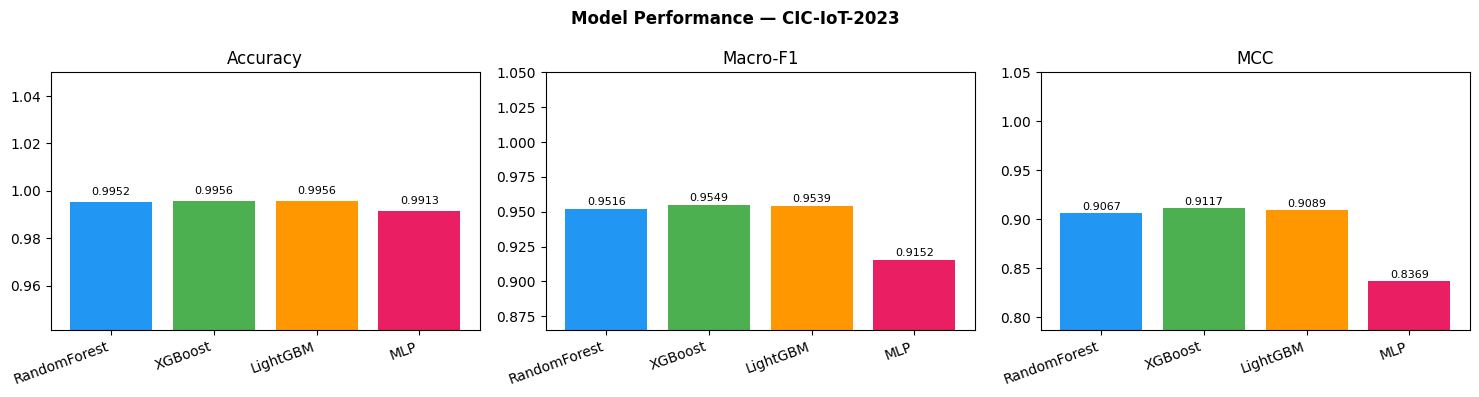

  SHAP [RandomForest] on CIC-IoT-2023...
  SHAP done in 13.2s
  Top-5: ['rst_count', 'urg_count', 'IAT', 'Magnitue', 'Weight']


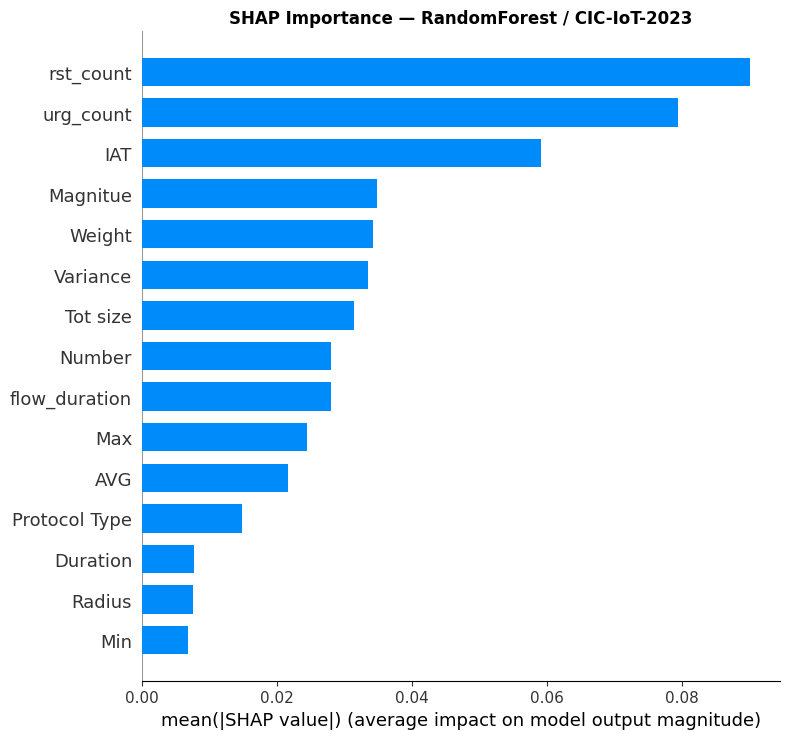

  LIME [RandomForest] on CIC-IoT-2023...
  LIME done | mean_lat=38.9ms | jaccard=0.204 | top5=['Variance', 'Weight', 'Max', 'Magnitue', 'AVG']


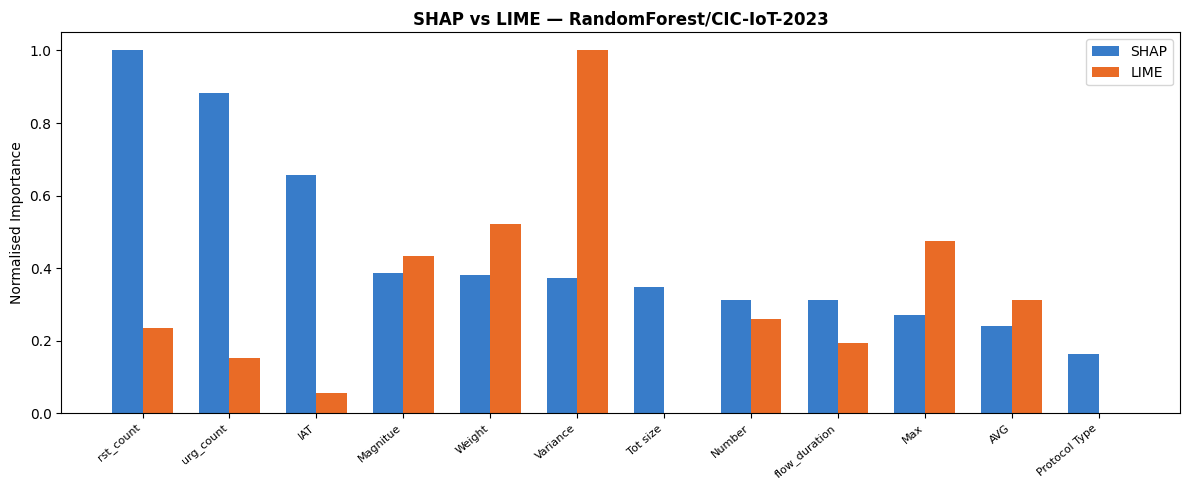

  SHAP [XGBoost] on CIC-IoT-2023...
  SHAP done in 0.1s
  Top-5: ['rst_count', 'Number', 'Tot size', 'Max', 'IAT']


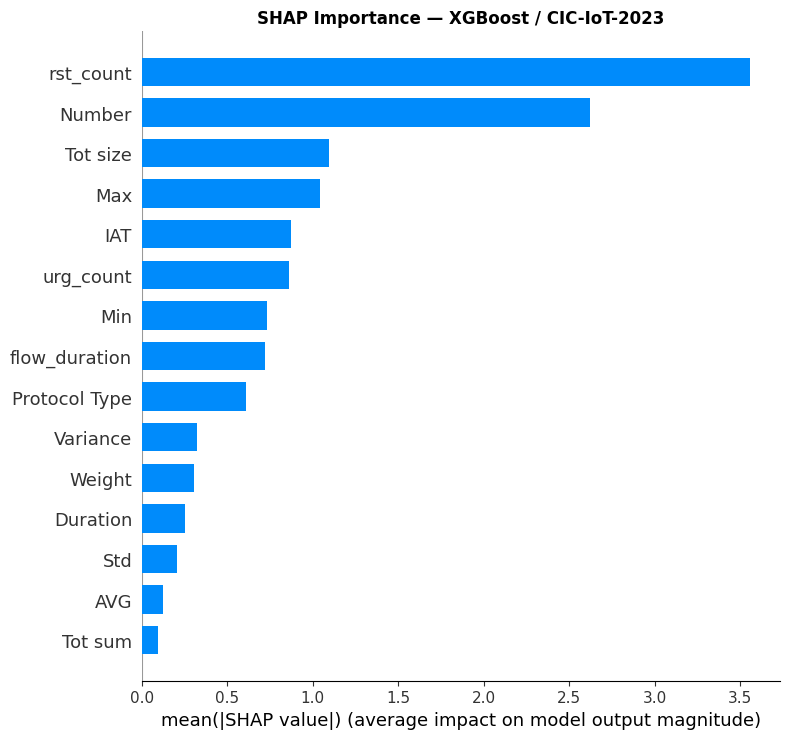

  SHAP [LightGBM] on CIC-IoT-2023...
  SHAP done in 0.3s
  Top-5: ['rst_count', 'IAT', 'Max', 'Number', 'urg_count']


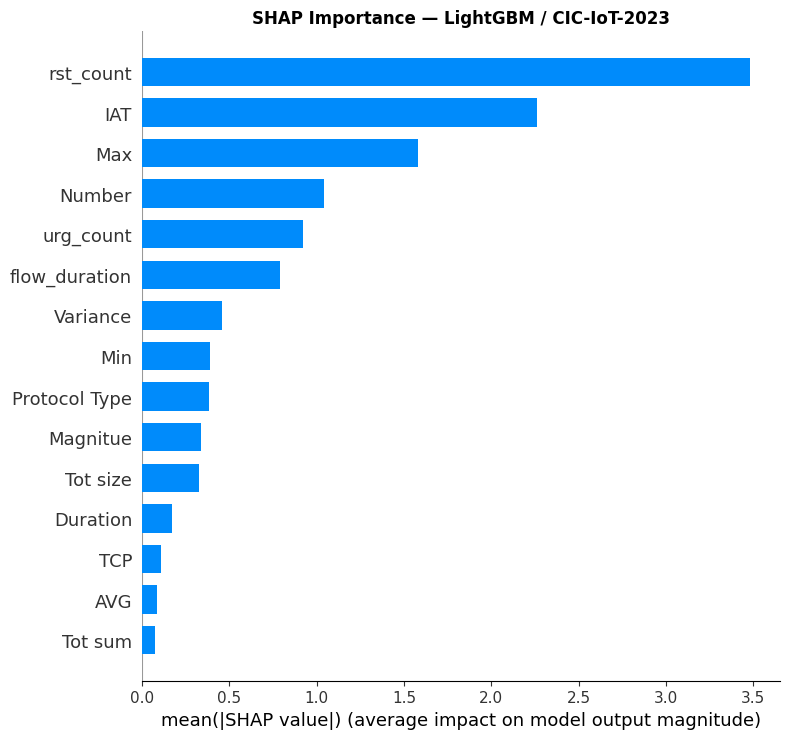

  LIME [LightGBM] on CIC-IoT-2023...
  LIME done | mean_lat=15.8ms | jaccard=0.197 | top5=['Number', 'Max', 'rst_count', 'Min', 'Duration']


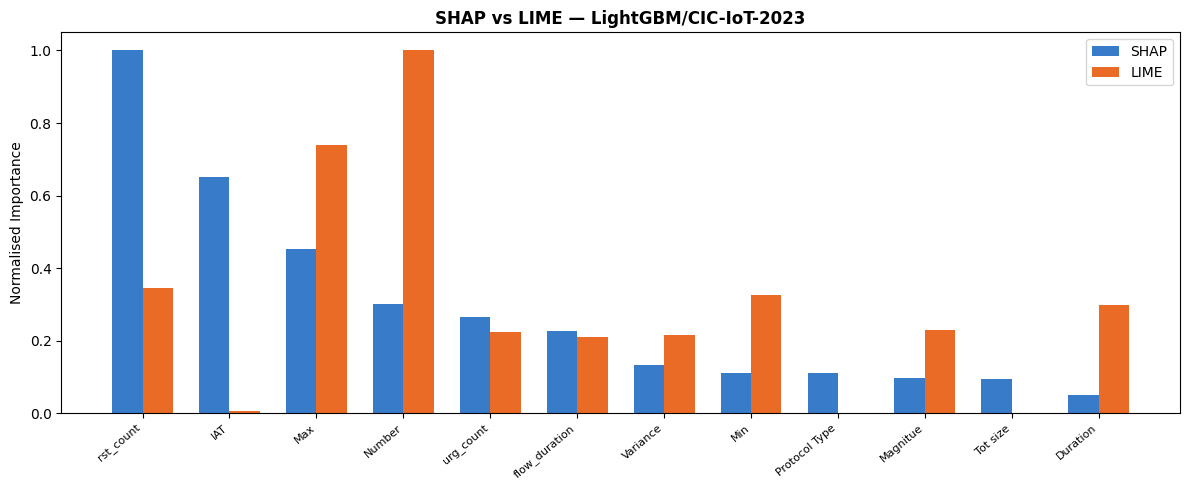

  SHAP [MLP] on CIC-IoT-2023...


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP done in 1.5s
  Top-5: ['rst_count', 'Weight', 'IAT', 'Max', 'urg_count']


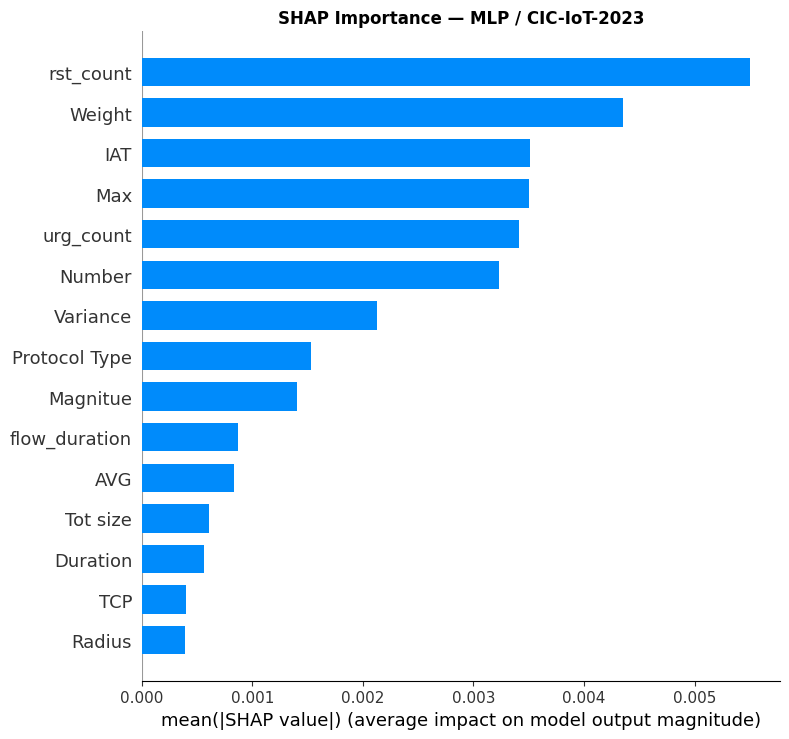

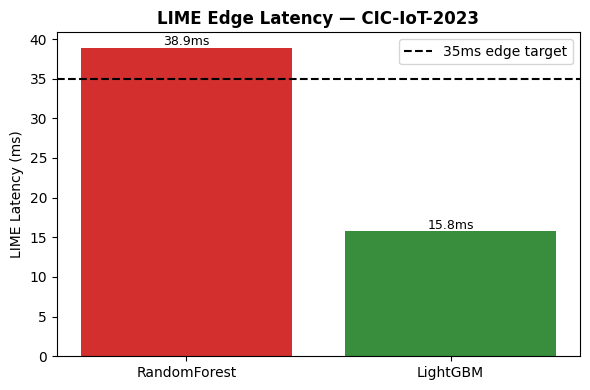

  Gap3 [LightGBM] on CIC-IoT-2023...
  Spearman rho=0.6694  p=0.0012  ⚠️  DISTORTED (rho<0.8)
  Gap3 [RandomForest] on CIC-IoT-2023...
  Spearman rho=0.9534  p=0.0000  ✅ OK


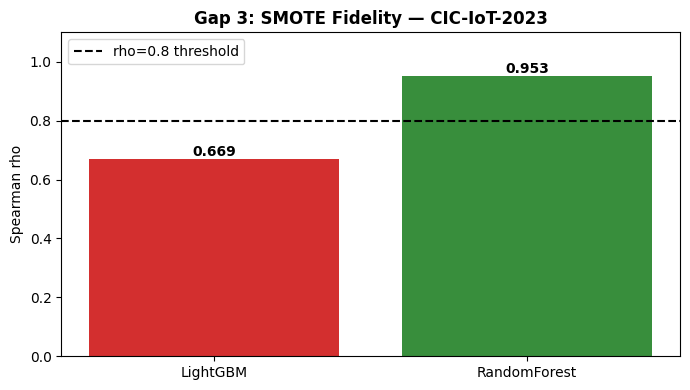


🔁 5-Fold CV [CIC-IoT-2023]
    [LightGBM] fold 1: F1=0.9514  MCC=0.9040  AUC=0.9993
    [LightGBM] fold 2: F1=0.9522  MCC=0.9061  AUC=0.9994
    [LightGBM] fold 3: F1=0.9531  MCC=0.9074  AUC=0.9994
    [LightGBM] fold 4: F1=0.9517  MCC=0.9045  AUC=0.9994
    [LightGBM] fold 5: F1=0.9506  MCC=0.9034  AUC=0.9994
  ✅ LightGBM: F1=0.9518±0.0009  MCC=0.9051±0.0015
    [RandomForest] fold 1: F1=0.9484  MCC=0.9007  AUC=0.9993
    [RandomForest] fold 2: F1=0.9479  MCC=0.9001  AUC=0.9993
    [RandomForest] fold 3: F1=0.9477  MCC=0.8993  AUC=0.9993
    [RandomForest] fold 4: F1=0.9500  MCC=0.9030  AUC=0.9993
    [RandomForest] fold 5: F1=0.9476  MCC=0.8995  AUC=0.9993
  ✅ RandomForest: F1=0.9483±0.0009  MCC=0.9006±0.0013
     Dataset        Model  CV_F1_mean  CV_F1_std  CV_MCC_mean  CV_MCC_std  CV_AUC_mean  CV_AUC_std
CIC-IoT-2023     LightGBM      0.9518     0.0009       0.9051      0.0015       0.9994         0.0
CIC-IoT-2023 RandomForest      0.9483     0.0009       0.9006      0.0013       

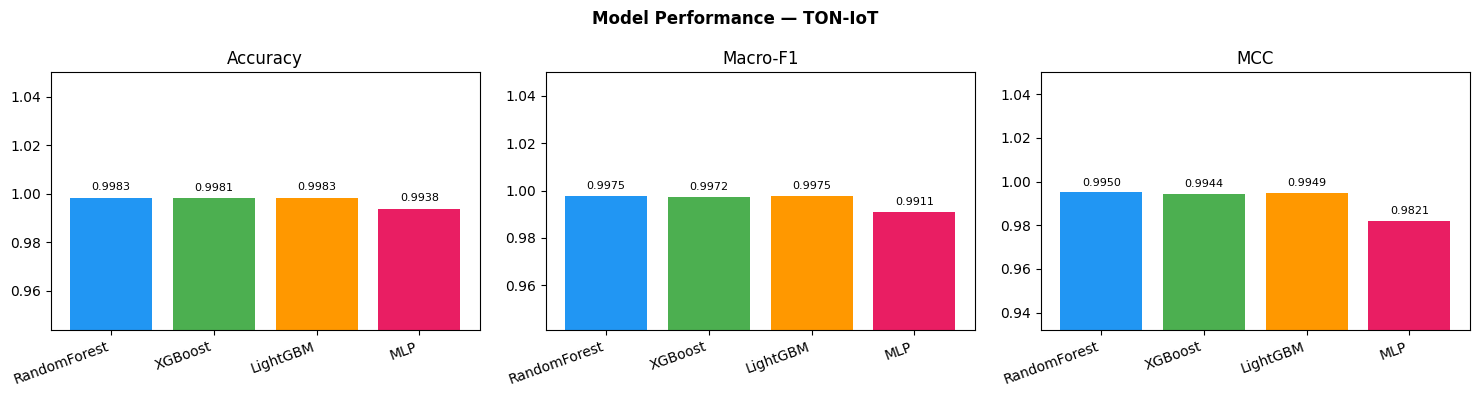

  SHAP [RandomForest] on TON-IoT...
  SHAP done in 12.6s
  Top-5: ['proto', 'dst_port', 'src_pkts', 'dns_qclass', 'src_ip_bytes']


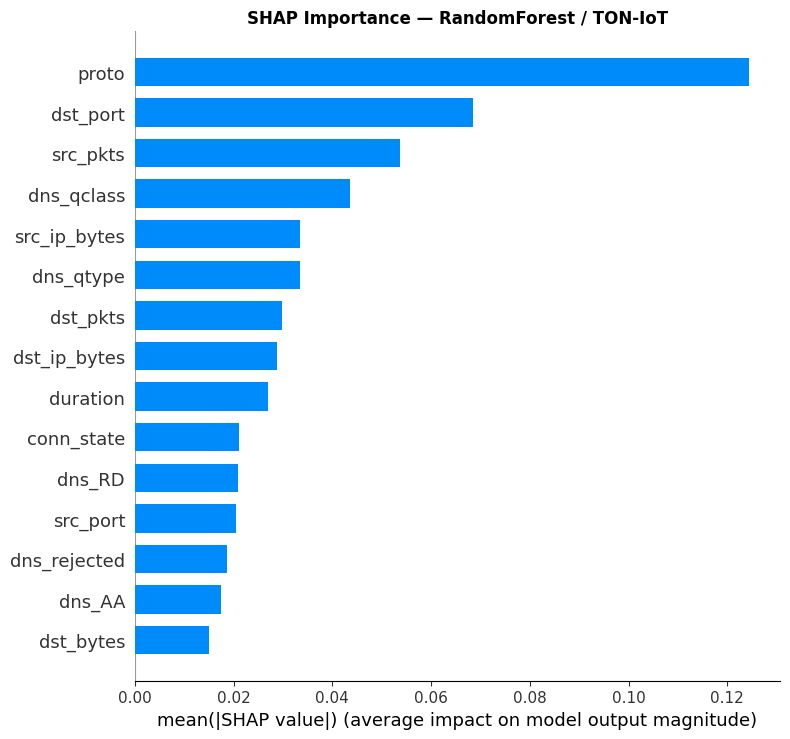

  LIME [RandomForest] on TON-IoT...
  LIME done | mean_lat=41.0ms | jaccard=0.272 | top5=['proto', 'src_pkts', 'duration', 'missed_bytes', 'dns_RD']


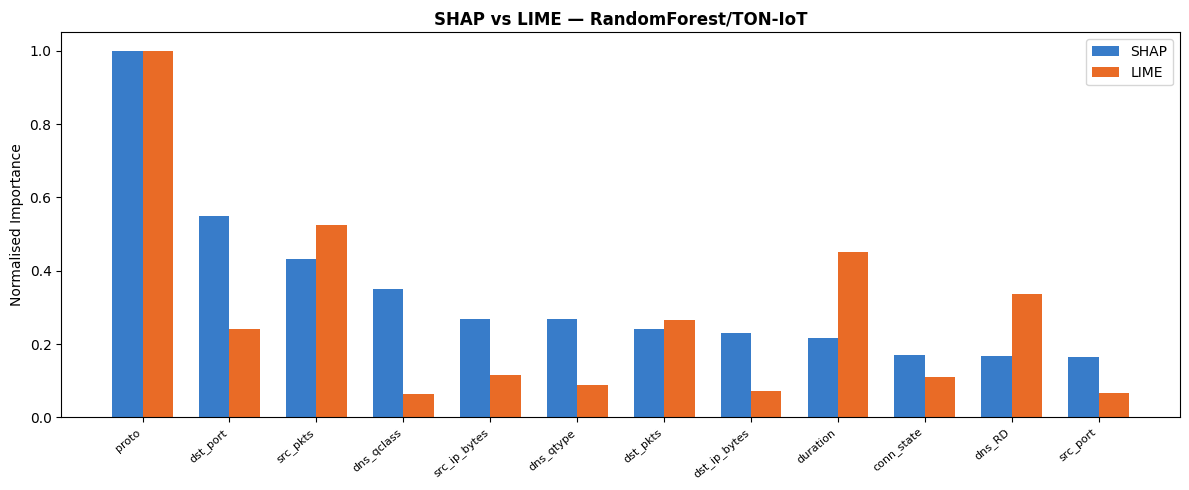

  SHAP [XGBoost] on TON-IoT...
  SHAP done in 0.1s
  Top-5: ['proto', 'dst_port', 'src_pkts', 'duration', 'src_ip_bytes']


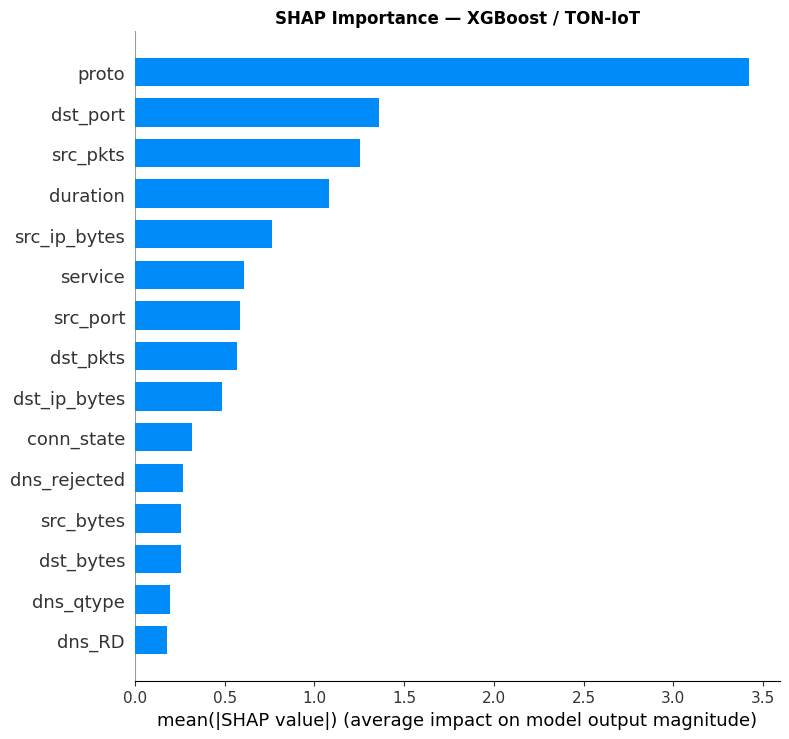

  SHAP [LightGBM] on TON-IoT...
  SHAP done in 0.3s
  Top-5: ['proto', 'src_pkts', 'dst_port', 'duration', 'dst_pkts']


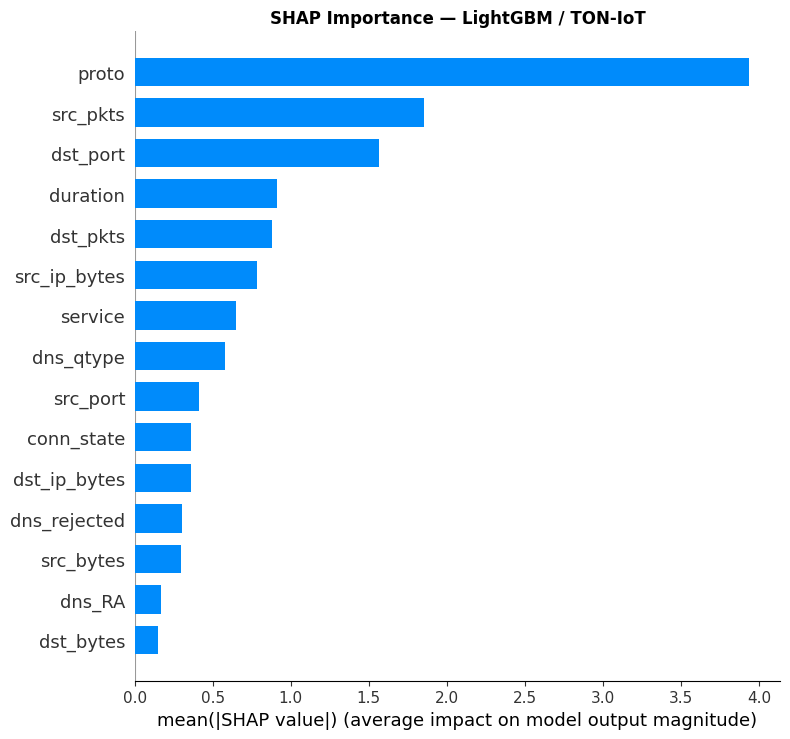

  LIME [LightGBM] on TON-IoT...
  LIME done | mean_lat=16.4ms | jaccard=0.327 | top5=['proto', 'dns_qtype', 'src_ip_bytes', 'missed_bytes', 'duration']


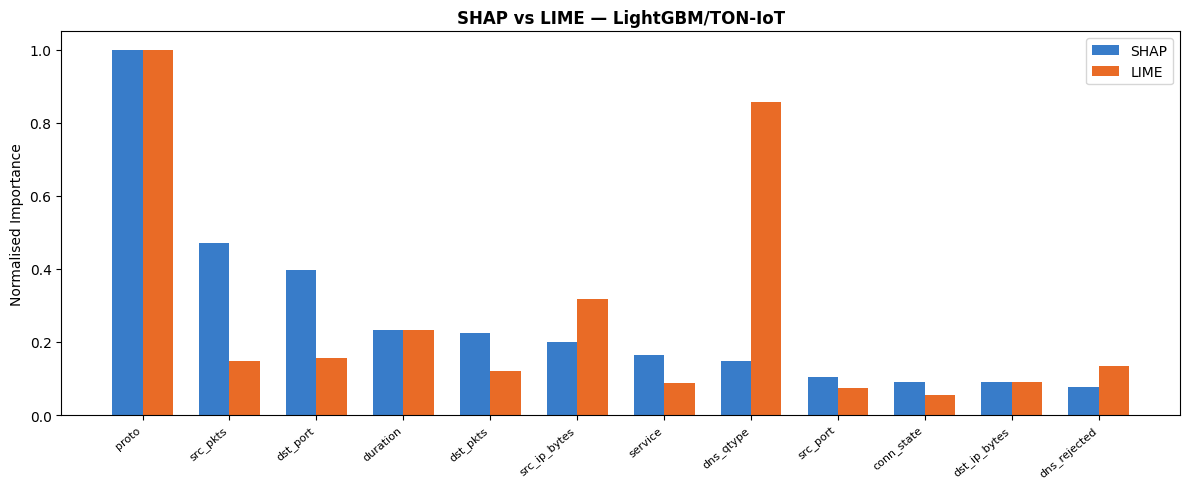

  SHAP [MLP] on TON-IoT...


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP done in 1.5s
  Top-5: ['proto', 'dst_port', 'dns_AA', 'src_port', 'conn_state']


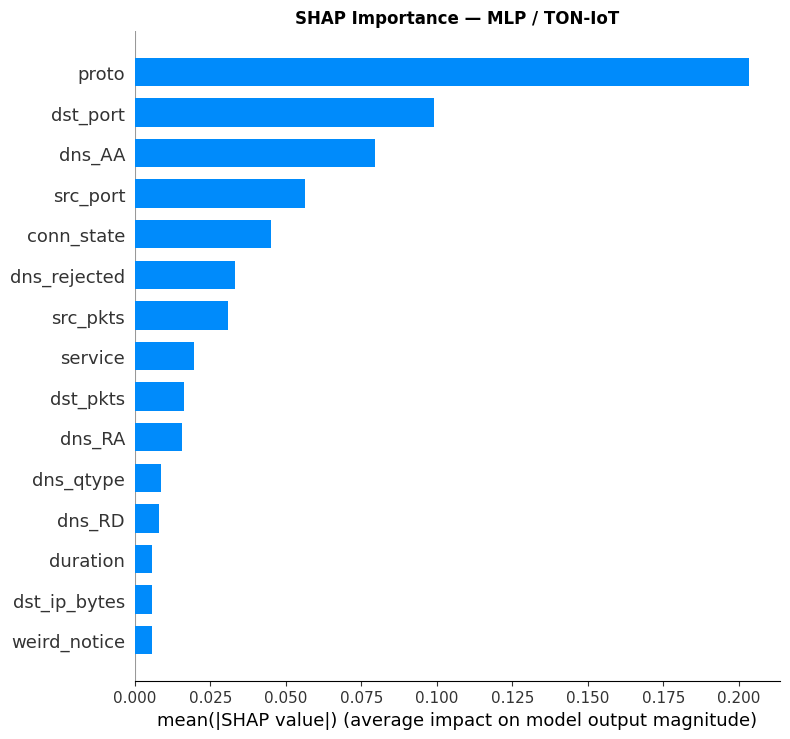

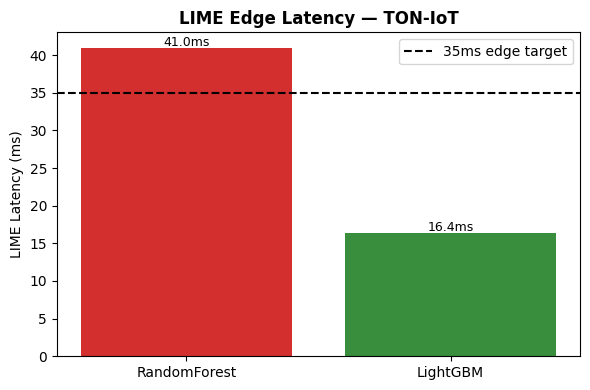

  Gap3 [LightGBM] on TON-IoT...
  Spearman rho=0.8556  p=0.0000  ✅ OK
  Gap3 [RandomForest] on TON-IoT...
  Spearman rho=0.9805  p=0.0000  ✅ OK


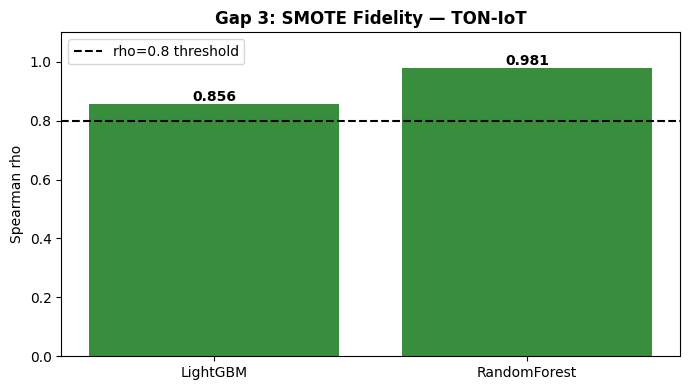


🔁 5-Fold CV [TON-IoT]
    [LightGBM] fold 1: F1=0.9982  MCC=0.9963  AUC=1.0000
    [LightGBM] fold 2: F1=0.9981  MCC=0.9961  AUC=0.9999
    [LightGBM] fold 3: F1=0.9973  MCC=0.9946  AUC=1.0000
    [LightGBM] fold 4: F1=0.9978  MCC=0.9955  AUC=1.0000
    [LightGBM] fold 5: F1=0.9976  MCC=0.9952  AUC=1.0000
  ✅ LightGBM: F1=0.9978±0.0003  MCC=0.9955±0.0006
    [RandomForest] fold 1: F1=0.9981  MCC=0.9961  AUC=1.0000
    [RandomForest] fold 2: F1=0.9982  MCC=0.9963  AUC=1.0000
    [RandomForest] fold 3: F1=0.9973  MCC=0.9945  AUC=1.0000
    [RandomForest] fold 4: F1=0.9978  MCC=0.9956  AUC=1.0000
    [RandomForest] fold 5: F1=0.9981  MCC=0.9961  AUC=1.0000
  ✅ RandomForest: F1=0.9979±0.0003  MCC=0.9957±0.0007
Dataset        Model  CV_F1_mean  CV_F1_std  CV_MCC_mean  CV_MCC_std  CV_AUC_mean  CV_AUC_std
TON-IoT     LightGBM      0.9978     0.0003       0.9955      0.0006          1.0         0.0
TON-IoT RandomForest      0.9979     0.0003       0.9957      0.0007          1.0         0.0



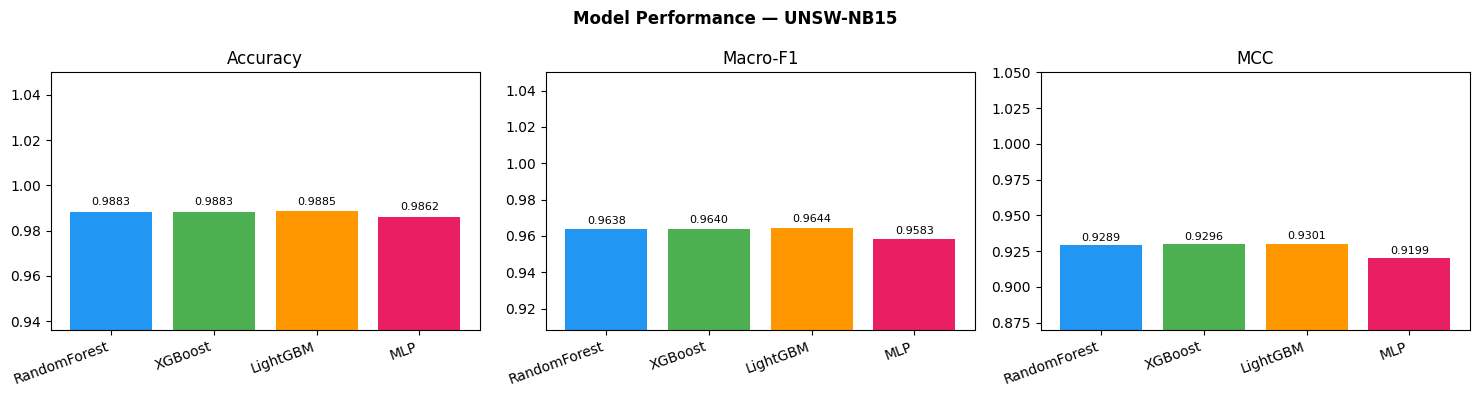

  SHAP [RandomForest] on UNSW-NB15...
  SHAP done in 35.0s
  Top-5: ['ct_state_ttl', 'sttl', 'dttl', 'Dpkts', 'dmeansz']


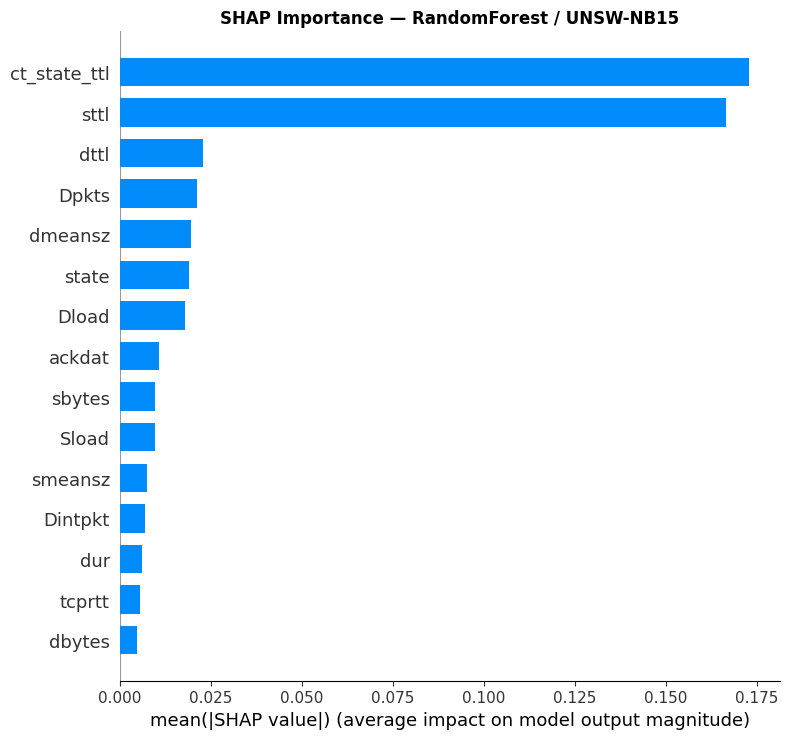

  LIME [RandomForest] on UNSW-NB15...
  LIME done | mean_lat=39.1ms | jaccard=0.334 | top5=['sttl', 'ct_state_ttl', 'synack', 'dur', 'Spkts']


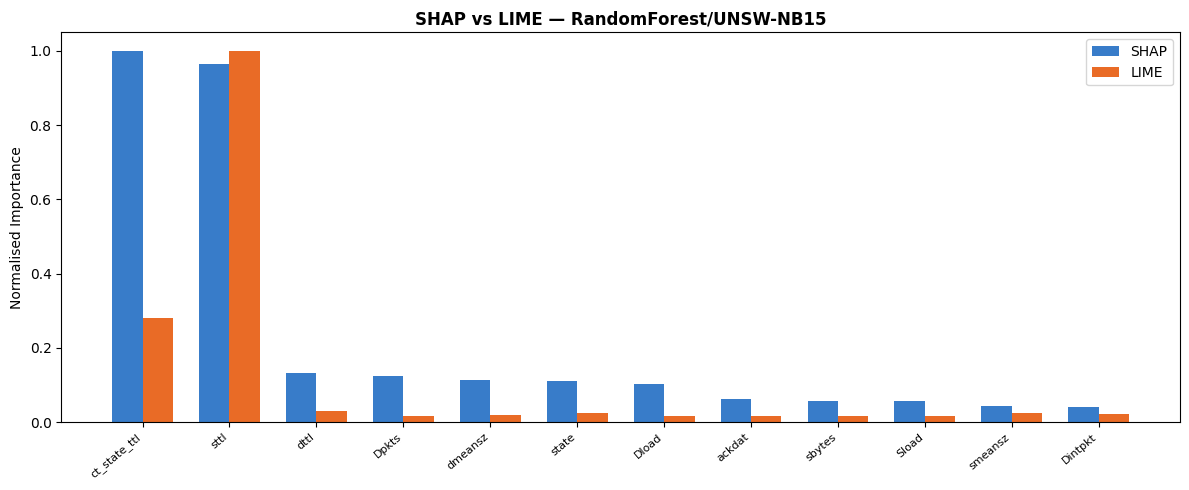

  SHAP [XGBoost] on UNSW-NB15...
  SHAP done in 0.1s
  Top-5: ['sttl', 'ct_state_ttl', 'dbytes', 'ct_dst_sport_ltm', 'Dpkts']


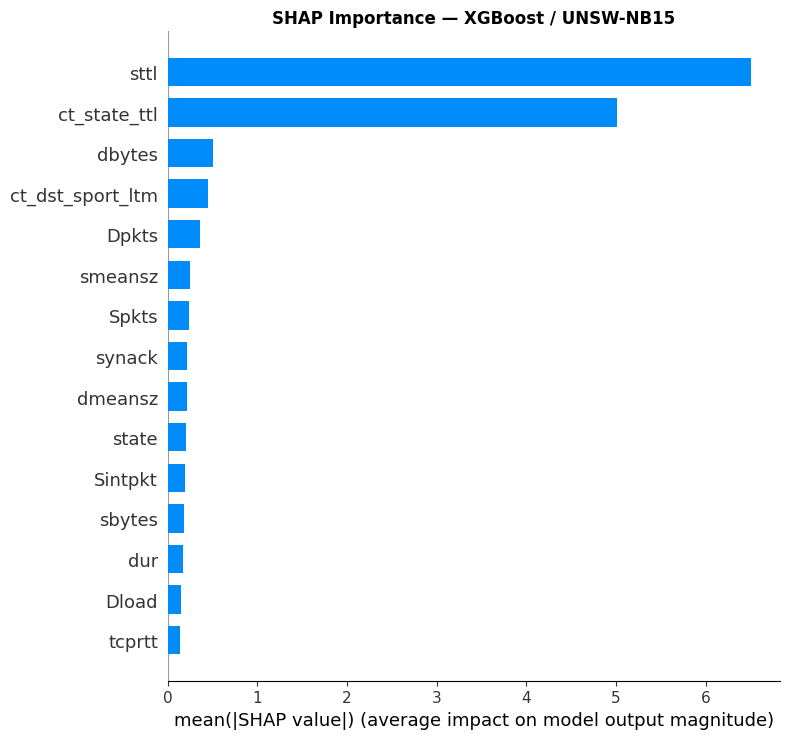

  SHAP [LightGBM] on UNSW-NB15...
  SHAP done in 0.3s
  Top-5: ['sttl', 'ct_state_ttl', 'ct_dst_sport_ltm', 'sbytes', 'dbytes']


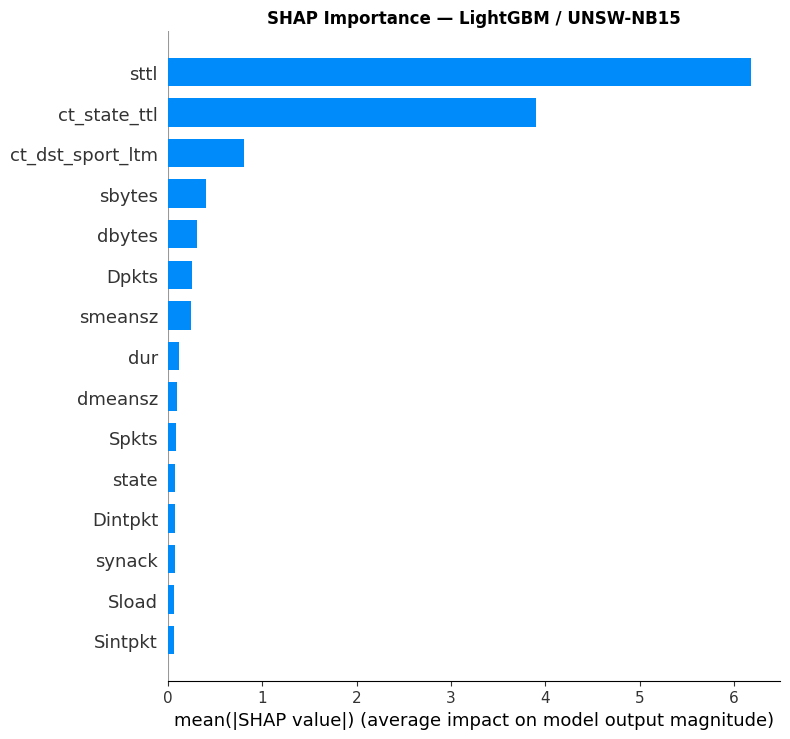

  LIME [LightGBM] on UNSW-NB15...
  LIME done | mean_lat=15.1ms | jaccard=0.233 | top5=['sttl', 'ct_state_ttl', 'ct_dst_sport_ltm', 'smeansz', 'dbytes']


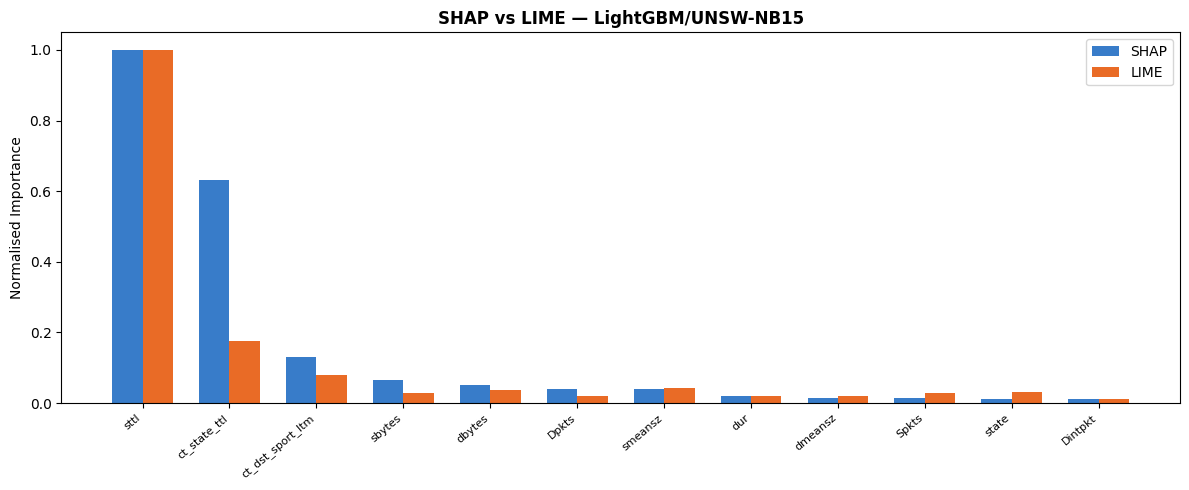

  SHAP [MLP] on UNSW-NB15...


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP done in 1.4s
  Top-5: ['ct_state_ttl', 'dttl', 'sttl', 'dwin', 'ct_dst_sport_ltm']


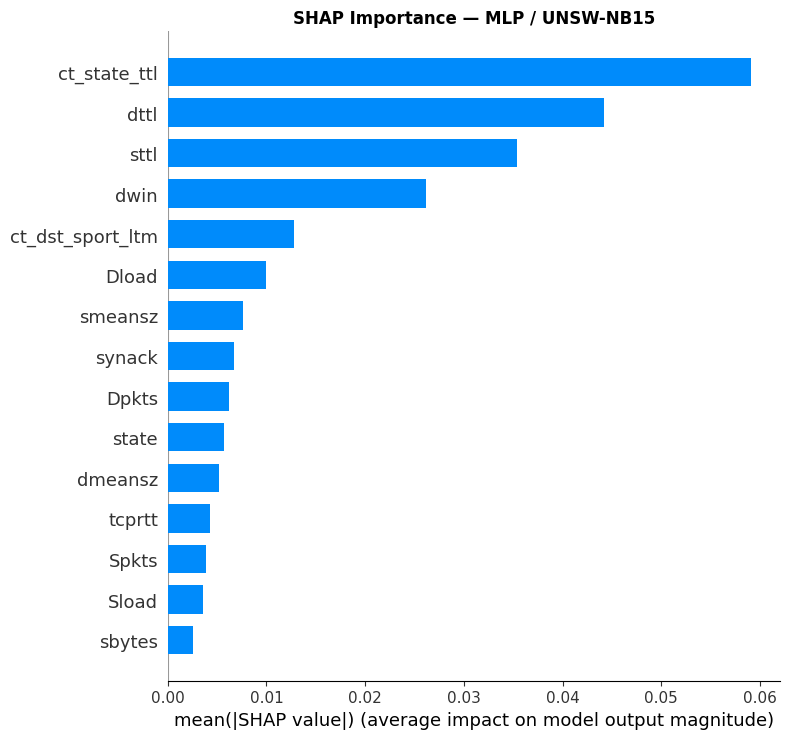

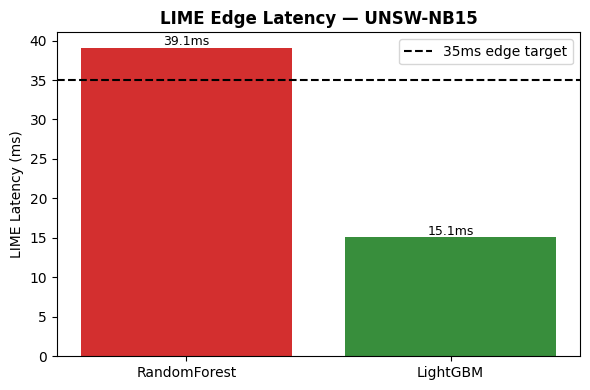

  Gap3 [LightGBM] on UNSW-NB15...
  Spearman rho=0.8827  p=0.0000  ✅ OK
  Gap3 [RandomForest] on UNSW-NB15...
  Spearman rho=0.8466  p=0.0000  ✅ OK


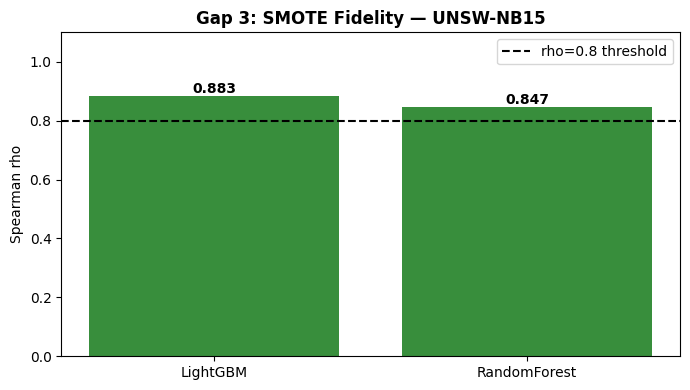


🔁 5-Fold CV [UNSW-NB15]
    [LightGBM] fold 1: F1=0.9686  MCC=0.9380  AUC=0.9989
    [LightGBM] fold 2: F1=0.9674  MCC=0.9358  AUC=0.9992
    [LightGBM] fold 3: F1=0.9661  MCC=0.9330  AUC=0.9992
    [LightGBM] fold 4: F1=0.9657  MCC=0.9324  AUC=0.9993
    [LightGBM] fold 5: F1=0.9646  MCC=0.9299  AUC=0.9991
  ✅ LightGBM: F1=0.9665±0.0014  MCC=0.9338±0.0028
    [RandomForest] fold 1: F1=0.9678  MCC=0.9368  AUC=0.9992
    [RandomForest] fold 2: F1=0.9655  MCC=0.9325  AUC=0.9992
    [RandomForest] fold 3: F1=0.9650  MCC=0.9315  AUC=0.9991
    [RandomForest] fold 4: F1=0.9650  MCC=0.9314  AUC=0.9992
    [RandomForest] fold 5: F1=0.9646  MCC=0.9301  AUC=0.9990
  ✅ RandomForest: F1=0.9656±0.0012  MCC=0.9325±0.0023
  Dataset        Model  CV_F1_mean  CV_F1_std  CV_MCC_mean  CV_MCC_std  CV_AUC_mean  CV_AUC_std
UNSW-NB15     LightGBM      0.9665     0.0014       0.9338      0.0028       0.9991      0.0001
UNSW-NB15 RandomForest      0.9656     0.0012       0.9325      0.0023       0.9991      

In [ ]:
# ── Dataset configuration ─────────────────────────────────────────────────────
PIPELINE_DATASETS = [
    {
        'name'         : 'CIC-IoT-2023',
        'path'         : '/content/datasets/ciciot2023',
        'label_col'    : 'label',
        'benign_values': ['BenignTraffic'],
    },
    {
        'name'         : 'TON-IoT',
        'path'         : '/content/datasets/toniot',
        'label_col'    : 'label',
        'benign_values': ['0', 'normal', 'Normal', 'benign', 'Benign'],
    },
    {
        'name'         : 'UNSW-NB15',
        'path'         : '/content/datasets/unswnb15_fixed',
        'label_col'    : 'label',
        'benign_values': ['0'],
    },
]

ALL_RESULTS   = {}
ALL_CV_RESULTS = []

for cfg in PIPELINE_DATASETS:
    ds_name = cfg['name']
    print(f'\n{"#"*70}')
    print(f'#  DATASET: {ds_name}')
    print(f'{"#"*70}')

    # ── 1. Load ───────────────────────────────────────────────────────────────
    try:
        df = load_csv_files(cfg['path'], sample_n=CONFIG['SAMPLE_SIZE'])
    except FileNotFoundError as e:
        print(f'Skipping: {e}')
        continue

    label_col = cfg.get('label_col') or detect_label_column(df)
    print(f'\n  Label col: "{label_col}"')
    print(f'  Unique values: {df[label_col].value_counts().head(10).index.tolist()}')
    dataset_info(df, label_col, ds_name)

    # ── 2. Preprocess ─────────────────────────────────────────────────────────
    try:
        (X_train, X_val, X_test, y_train, y_val, y_test,
         feat_names, le, scaler, X_pre, y_pre) = preprocess(
            df, label_col,
            benign_values=cfg.get('benign_values'),
            top_k=CONFIG['TOP_K_FEATURES'],
            apply_smote=True, seed=SEED, name=ds_name)
    except RuntimeError as e:
        print(f'\n❌ Preprocessing failed: {e}\nSkipping.'); continue

    # ── 3. Leakage check  ← NEW ───────────────────────────────────────────────
    flagged = check_leakage(X_test, y_test, feat_names, threshold=0.95,
                            name=ds_name)
    explain_perfect_scores(ds_name, flagged)

    del df; gc.collect()

    # ── 4. Train ──────────────────────────────────────────────────────────────
    models = get_models(SEED)
    df_res, trained = train_models(
        models, X_train, X_val, X_test,
        y_train, y_val, y_test, ds_name)
    plot_metrics(df_res, ds_name)

    # ── 5. SHAP + LIME ────────────────────────────────────────────────────────
    shap_res, lime_res, lime_lats = {}, {}, {}

    for mname, model in trained.items():
        sv, shap_imp, X_exp = run_shap(
            model, mname, X_test, feat_names,
            n=CONFIG['SHAP_N_EXPLAIN'], ds=ds_name)
        shap_res[mname] = (sv, shap_imp)
        if sv is not None:
            plot_shap_bar(sv, X_exp, feat_names, mname, ds_name)

        if mname in ['LightGBM', 'RandomForest']:
            lime_imp, lat, jac = run_lime(
                model, X_train, X_test, feat_names,
                n_explain=CONFIG['LIME_N_EXPLAIN'],
                n_samples=CONFIG['LIME_N_SAMPLES'],
                ds=ds_name, mname=mname)
            lime_res[mname]  = (lime_imp, jac)
            lime_lats[mname] = lat
            if shap_imp:
                plot_shap_vs_lime(shap_imp, lime_imp, mname, ds_name)

    plot_latency(lime_lats, ds_name)

    # ── 6. Gap 3 — SMOTE Fidelity ────────────────────────────────────────────
    fid_res = {}
    for mname in ['LightGBM', 'RandomForest']:
        if mname not in trained: continue
        if mname == 'LightGBM':
            mc = lgb.LGBMClassifier
            mp = dict(n_estimators=200, num_leaves=31,
                      min_child_samples=20, learning_rate=0.1,
                      class_weight='balanced', random_state=SEED,
                      n_jobs=-1, verbose=-1)
        else:
            mc = RandomForestClassifier
            mp = dict(n_estimators=CONFIG['RF_TREES'],
                      max_features='sqrt', max_depth=20,
                      n_jobs=-1, random_state=SEED,
                      class_weight='balanced')
        fid_res[mname] = gap3_fidelity(
            mc, mp, X_pre, y_pre, X_train, y_train,
            X_test, feat_names, ds=ds_name, mname=mname)
    plot_gap3(fid_res, ds_name)

    # ── 7. Cross-Validation  ← NEW ───────────────────────────────────────────
    # Use pre-SMOTE full data (X_pre + X_test) so CV is on original distribution
    X_cv = np.vstack([X_pre, X_test])
    y_cv = np.concatenate([y_pre, y_test])
    cv_df = run_cv(X_cv, y_cv, ds_name, n_folds=CONFIG['CV_FOLDS'], seed=SEED)
    ALL_CV_RESULTS.append(cv_df)
    print(cv_df.to_string(index=False))

    # ── 8. Store everything in ALL_RESULTS ───────────────────────────────────
    ALL_RESULTS[ds_name] = {
        'metrics'      : df_res,
        'trained'      : trained,
        'trained_models': trained,        # alias for export cell
        'scaler'       : scaler,
        'feature_names': feat_names,
        'fidelity'     : fid_res,
        'lime'         : lime_res,
        'latencies'    : lime_lats,
        'shap'         : shap_res,
        'leakage'      : flagged,
        'X_test'       : X_test,
        'y_test'       : y_test,
        'X_train'      : X_train,
        'y_train'      : y_train,
    }
    print(f'\n✅ {ds_name} complete — stored in ALL_RESULTS')
    gc.collect()

print('\n' + '='*70)
print('🎉 ALL DATASETS COMPLETE')
print('='*70)
print(f'Datasets processed: {list(ALL_RESULTS.keys())}')


## 📋 CELL 14: Master Results Table + Complete CSV

     Dataset        Model  Accuracy  Macro-F1  Precision  Recall    MCC  AUC-ROC  Train(s)  Latency(ms) SHAP_rho Fidelity_OK LIME_Jaccard LIME_ms  Leakage
CIC-IoT-2023 RandomForest    0.9952    0.9516     0.9174  0.9924 0.9067   0.9993   19.5000       0.0356   0.9534         YES       0.2040 38.9000    False
CIC-IoT-2023      XGBoost    0.9956    0.9549     0.9287  0.9847 0.9117   0.9994    1.3000       0.0075        -           -            -       -    False
CIC-IoT-2023     LightGBM    0.9956    0.9539     0.9341  0.9758 0.9089   0.9994    2.0000       0.0025   0.6694          NO       0.1970 15.8000    False
CIC-IoT-2023          MLP    0.9913    0.9152     0.8719  0.9708 0.8369   0.9975  132.3000       0.0016        -           -            -       -    False
     TON-IoT RandomForest    0.9983    0.9975     0.9978  0.9973 0.9950   1.0000    2.6000       0.0355   0.9805         YES       0.2720 41.0000    False
     TON-IoT      XGBoost    0.9981    0.9972     0.9972  0.9972 0.994

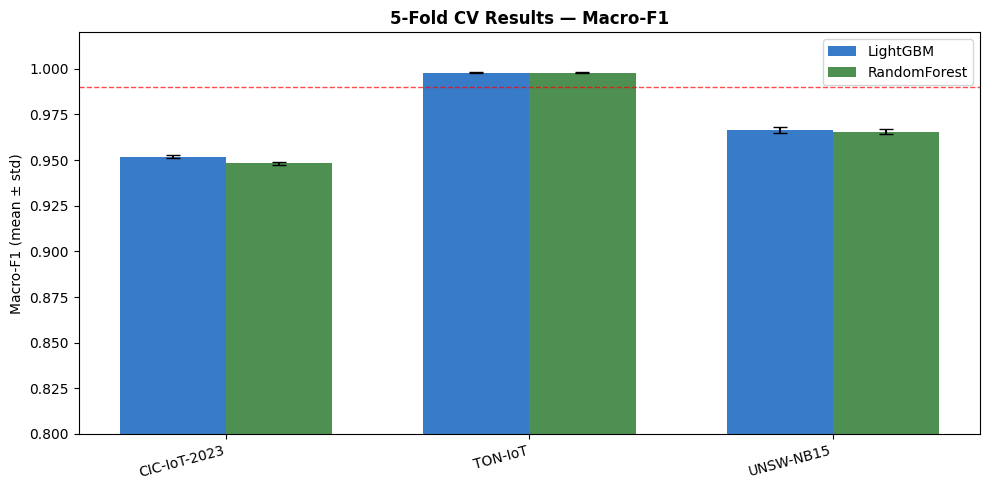

In [ ]:
rows = []
for ds_name, dr in ALL_RESULTS.items():
    for mname, row in dr['metrics'].iterrows():
        r = {'Dataset': ds_name, 'Model': mname}
        r.update({k: row.get(k, '-')
                  for k in ['Accuracy','Macro-F1','Precision','Recall',
                             'MCC','AUC-ROC','Train(s)','Latency(ms)']})
        fd = dr['fidelity'].get(mname)
        r['SHAP_rho']    = fd['rho']                         if fd else '-'
        r['Fidelity_OK'] = ('YES' if not fd['distorted'] else 'NO') if fd else '-'
        lr = dr['lime'].get(mname)
        r['LIME_Jaccard'] = round(lr[1], 3) if lr else '-'
        r['LIME_ms']      = round(dr['latencies'].get(mname, 0), 1)                             if mname in dr['latencies'] else '-'
        r['Leakage']      = len(dr.get('leakage', [])) > 0
        rows.append(r)

summary = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary.to_string(index=False))
summary.to_csv('/content/master_results.csv', index=False)
print('\n✅ Saved: /content/master_results.csv')

# ── CV results ────────────────────────────────────────────────────────────────
if ALL_CV_RESULTS:
    cv_master = pd.concat(ALL_CV_RESULTS, ignore_index=True)
    print('\n' + '='*60)
    print('5-FOLD CROSS-VALIDATION RESULTS')
    print('='*60)
    print(cv_master.to_string(index=False))
    cv_master.to_csv('/content/cv_results.csv', index=False)
    print('\n✅ Saved: /content/cv_results.csv')
    plot_cv_results(cv_master)


## 📊 CELL 15: Cross-Dataset Heatmaps

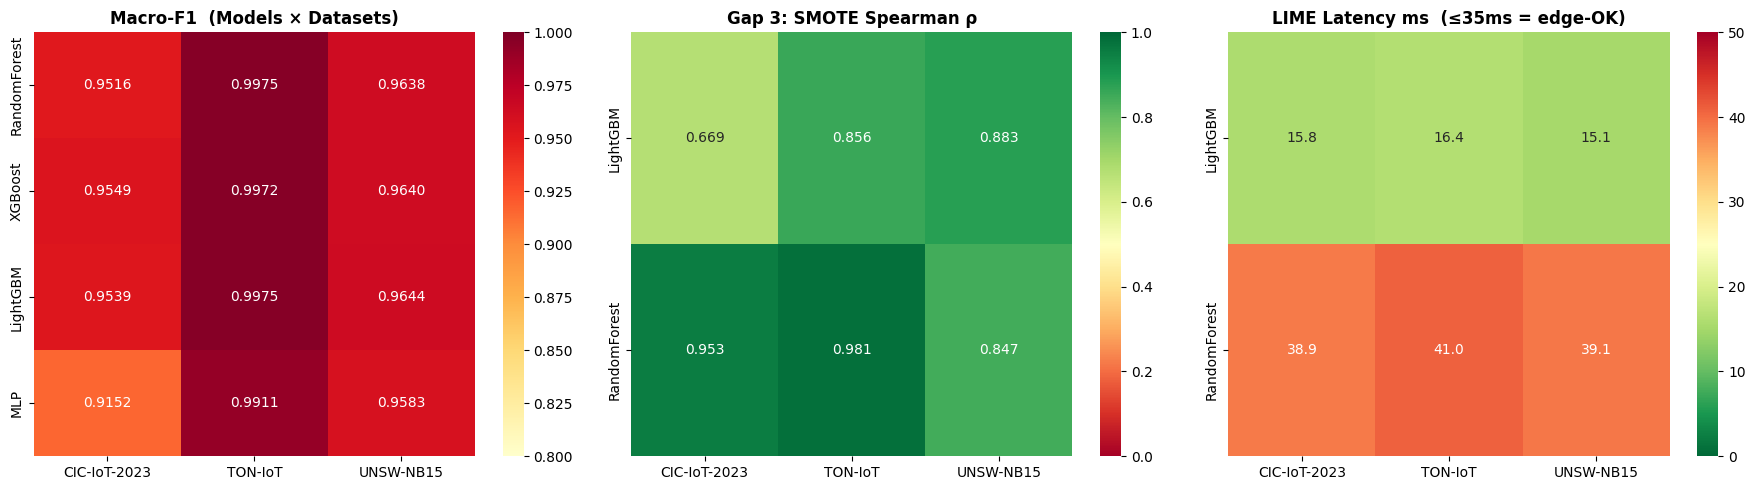

✅ Saved: /content/cross_dataset_heatmap.png


In [ ]:
if ALL_RESULTS:
    datasets    = list(ALL_RESULTS.keys())
    model_names = ['RandomForest','XGBoost','LightGBM','MLP']

    f1_mat  = pd.DataFrame(index=model_names, columns=datasets, dtype=float)
    rho_mat = pd.DataFrame(index=['LightGBM','RandomForest'],
                           columns=datasets, dtype=float)
    lat_mat = pd.DataFrame(index=['LightGBM','RandomForest'],
                           columns=datasets, dtype=float)

    for ds in datasets:
        for m in model_names:
            try:
                f1_mat.loc[m, ds] = float(ALL_RESULTS[ds]['metrics'].loc[m,'Macro-F1'])
            except: pass
        for m in ['LightGBM','RandomForest']:
            fd = ALL_RESULTS[ds]['fidelity'].get(m)
            if fd: rho_mat.loc[m, ds] = fd['rho']
            lt = ALL_RESULTS[ds]['latencies'].get(m)
            if lt: lat_mat.loc[m, ds] = lt

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(f1_mat.astype(float), annot=True, fmt='.4f',
                cmap='YlOrRd', ax=ax[0], vmin=0.8, vmax=1.0)
    ax[0].set_title('Macro-F1  (Models × Datasets)', fontweight='bold')

    sns.heatmap(rho_mat.astype(float), annot=True, fmt='.3f',
                cmap='RdYlGn', ax=ax[1], vmin=0, vmax=1.0)
    ax[1].set_title('Gap 3: SMOTE Spearman ρ', fontweight='bold')

    sns.heatmap(lat_mat.astype(float), annot=True, fmt='.1f',
                cmap='RdYlGn_r', ax=ax[2], vmin=0, vmax=50)
    ax[2].set_title('LIME Latency ms  (≤35ms = edge-OK)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/cross_dataset_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: /content/cross_dataset_heatmap.png')


## 📝 CELL 16: Research Gap Analysis Printout

In [ ]:
print('RESEARCH GAP ANALYSIS')
print('='*70)

print('\nGAP 1 — Multi-dataset validation:')
for ds in ALL_RESULTS:
    print(f'  [{ds}] ✅ trained and evaluated')

print('\nGAP 2 — Joint SHAP+LIME benchmarking:')
for ds_name, dr in ALL_RESULTS.items():
    print(f'  [{ds_name}]')
    for m, lat in dr['latencies'].items():
        status = '✅ Edge-OK (≤35ms)' if lat <= 35 else '❌ Too slow (>35ms)'
        print(f'    {m}: LIME={lat:.1f}ms → {status}')

print('\nGAP 3 — SMOTE Fidelity Paradox:')
for ds_name, dr in ALL_RESULTS.items():
    for m, fd in dr['fidelity'].items():
        status = '⚠️  DISTORTED' if fd['distorted'] else '✅ OK'
        print(f'  [{ds_name}] {m}: rho={fd["rho"]} → {status}')
        print(f'    pre-SMOTE  top5: {fd["pre_top5"]}')
        print(f'    post-SMOTE top5: {fd["post_top5"]}')

print('\nGAP 4 — XAI→Automated Mitigation:')
print('  Top SHAP features map to firewall rule templates.')
print('  Implementation left for future work (see paper Section 5).')

print('\nLEAKAGE AUDIT:')
for ds_name, dr in ALL_RESULTS.items():
    n = len(dr.get('leakage', []))
    print(f'  [{ds_name}]: {n} feature(s) flagged at rho>0.95')
    for fname, rho in dr.get('leakage', []):
        print(f'    {fname}  rho={rho}')

print('\n5-FOLD CV SUMMARY:')
if ALL_CV_RESULTS:
    cv_master = pd.concat(ALL_CV_RESULTS)
    for _, row in cv_master.iterrows():
        print(f'  [{row.Dataset}] {row.Model}: '
              f'F1={row.CV_F1_mean:.4f}±{row.CV_F1_std:.4f}  '
              f'MCC={row.CV_MCC_mean:.4f}±{row.CV_MCC_std:.4f}')

print('\nAll plots saved to /content/*.png')
print('CSV files: master_results.csv  cv_results.csv')


RESEARCH GAP ANALYSIS

GAP 1 — Multi-dataset validation:
  [CIC-IoT-2023] ✅ trained and evaluated
  [TON-IoT] ✅ trained and evaluated
  [UNSW-NB15] ✅ trained and evaluated

GAP 2 — Joint SHAP+LIME benchmarking:
  [CIC-IoT-2023]
    RandomForest: LIME=38.9ms → ❌ Too slow (>35ms)
    LightGBM: LIME=15.8ms → ✅ Edge-OK (≤35ms)
  [TON-IoT]
    RandomForest: LIME=41.0ms → ❌ Too slow (>35ms)
    LightGBM: LIME=16.4ms → ✅ Edge-OK (≤35ms)
  [UNSW-NB15]
    RandomForest: LIME=39.1ms → ❌ Too slow (>35ms)
    LightGBM: LIME=15.1ms → ✅ Edge-OK (≤35ms)

GAP 3 — SMOTE Fidelity Paradox:
  [CIC-IoT-2023] LightGBM: rho=0.6694 → ⚠️  DISTORTED
    pre-SMOTE  top5: ['Max', 'Protocol Type', 'rst_count', 'IAT', 'flow_duration']
    post-SMOTE top5: ['rst_count', 'IAT', 'Max', 'Number', 'urg_count']
  [CIC-IoT-2023] RandomForest: rho=0.9534 → ✅ OK
    pre-SMOTE  top5: ['rst_count', 'IAT', 'urg_count', 'Tot size', 'Magnitue']
    post-SMOTE top5: ['rst_count', 'urg_count', 'IAT', 'Magnitue', 'Weight']
  [TON-I

## 💾 CELL 17: Save Models for Deployment ← NEW
Saves LightGBM + RandomForest models, scalers, and feature lists for all 3 datasets.

In [ ]:
import joblib, json, os
from pathlib import Path

os.makedirs('/content/exported_models', exist_ok=True)

DATASET_SLUGS = {
    'CIC-IoT-2023': 'ciciot2023',
    'TON-IoT'     : 'toniot',
    'UNSW-NB15'   : 'unswnb15',
}
MODEL_SLUGS = {
    'LightGBM'    : 'lightgbm',
    'RandomForest': 'randomforest',
}

print('📦 Saving models...')
for ds_name, ds_slug in DATASET_SLUGS.items():
    if ds_name not in ALL_RESULTS:
        print(f'⚠️  {ds_name} not in ALL_RESULTS — skipping')
        continue
    dr = ALL_RESULTS[ds_name]
    print(f'\n── {ds_name} → {ds_slug} ──')

    # Scaler
    scaler_path = f'/content/exported_models/{ds_slug}_scaler.pkl'
    joblib.dump(dr['scaler'], scaler_path)
    print(f'  ✅ {ds_slug}_scaler.pkl')

    # Feature names
    feat_path = f'/content/exported_models/{ds_slug}_features.json'
    with open(feat_path, 'w') as f:
        json.dump(dr['feature_names'], f)
    print(f'  ✅ {ds_slug}_features.json  ({len(dr["feature_names"])} features)')

    # Models
    for mname, mslug in MODEL_SLUGS.items():
        if mname in dr.get('trained_models', dr.get('trained', {})):
            model_obj = dr.get('trained_models', dr.get('trained', {}))[mname]
            mpath = f'/content/exported_models/{ds_slug}_{mslug}_model.pkl'
            joblib.dump(model_obj, mpath, compress=3)
            size_mb = os.path.getsize(mpath) / 1e6
            print(f'  ✅ {ds_slug}_{mslug}_model.pkl  ({size_mb:.1f} MB)')

# Zip
zip_path = '/content/exported_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in Path('/content/exported_models').glob('*'):
        zf.write(str(f), f.name)

total_mb = os.path.getsize(zip_path) / 1e6
print(f'\n✅ exported_models.zip  ({total_mb:.1f} MB)')
print('Files:')
for f in sorted(Path('/content/exported_models').glob('*')):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

from google.colab import files as colab_files
colab_files.download(zip_path)


📦 Saving models...

── CIC-IoT-2023 → ciciot2023 ──
  ✅ ciciot2023_scaler.pkl
  ✅ ciciot2023_features.json  (20 features)
  ✅ ciciot2023_lightgbm_model.pkl  (0.3 MB)
  ✅ ciciot2023_randomforest_model.pkl  (2.0 MB)

── TON-IoT → toniot ──
  ✅ toniot_scaler.pkl
  ✅ toniot_features.json  (20 features)
  ✅ toniot_lightgbm_model.pkl  (0.3 MB)
  ✅ toniot_randomforest_model.pkl  (2.0 MB)

── UNSW-NB15 → unswnb15 ──
  ✅ unswnb15_scaler.pkl
  ✅ unswnb15_features.json  (20 features)
  ✅ unswnb15_lightgbm_model.pkl  (0.3 MB)
  ✅ unswnb15_randomforest_model.pkl  (4.3 MB)

✅ exported_models.zip  (9.2 MB)
Files:
  ciciot2023_features.json  (0.0 MB)
  ciciot2023_lightgbm_model.pkl  (0.3 MB)
  ciciot2023_randomforest_model.pkl  (2.0 MB)
  ciciot2023_scaler.pkl  (0.0 MB)
  toniot_features.json  (0.0 MB)
  toniot_lightgbm_model.pkl  (0.3 MB)
  toniot_randomforest_model.pkl  (2.0 MB)
  toniot_scaler.pkl  (0.0 MB)
  unswnb15_features.json  (0.0 MB)
  unswnb15_lightgbm_model.pkl  (0.3 MB)
  unswnb15_random

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔄 CELL 18: Export to ONNX ← NEW
ONNX enables deployment on ARM edge hardware (Raspberry Pi, Jetson Nano) without Python/sklearn.

In [ ]:
import os
import numpy as np
from pathlib import Path

os.makedirs('/content/onnx_models', exist_ok=True)

DATASET_SLUGS = {
    'CIC-IoT-2023': 'ciciot2023',
    'TON-IoT'     : 'toniot',
    'UNSW-NB15'   : 'unswnb15',
}

print('🔄 Exporting LightGBM models to ONNX...')
onnx_exported = []

for ds_name, ds_slug in DATASET_SLUGS.items():
    if ds_name not in ALL_RESULTS:
        print(f'⚠️  {ds_name} not in ALL_RESULTS — skipping')
        continue

    dr = ALL_RESULTS[ds_name]
    models_dict = dr.get('trained_models', dr.get('trained', {}))

    for mname in ['LightGBM', 'RandomForest']:
        if mname not in models_dict:
            continue
        model = models_dict[mname]
        n_features = len(dr['feature_names'])
        onnx_path  = f'/content/onnx_models/{ds_slug}_{mname.lower()}.onnx'

        try:
            if mname == 'LightGBM':
                # LightGBM native ONNX export
                model.booster_.save_model('/tmp/lgbm_tmp.txt')
                import lightgbm as lgb_mod
                booster = lgb_mod.Booster(model_file='/tmp/lgbm_tmp.txt')
                booster.save_model(onnx_path.replace('.onnx', '.lgbm.txt'))
                # Use onnxmltools for proper ONNX
                from onnxmltools import convert_lightgbm
                from onnxmltools.utils import save_model as save_onnx
                from skl2onnx.common.data_types import FloatTensorType
                initial_types = [('float_input',
                                  FloatTensorType([None, n_features]))]
                onnx_model = convert_lightgbm(
                    model, initial_types=initial_types,
                    target_opset=12)
                save_onnx(onnx_model, onnx_path)

            else:  # RandomForest
                from skl2onnx import convert_sklearn
                from skl2onnx.common.data_types import FloatTensorType
                initial_types = [('float_input',
                                  FloatTensorType([None, n_features]))]
                onnx_model = convert_sklearn(model, initial_types=initial_types,
                                             target_opset=12)
                with open(onnx_path, 'wb') as f:
                    f.write(onnx_model.SerializeToString())

            # Verify ONNX output matches sklearn output
            import onnxruntime as ort
            sess  = ort.InferenceSession(onnx_path)
            X_chk = dr['X_test'][:5].astype(np.float32)
            inp_name = sess.get_inputs()[0].name
            onnx_pred = sess.run(None, {inp_name: X_chk})[0]
            skl_pred  = model.predict(X_chk)
            match = np.array_equal(onnx_pred.ravel(), skl_pred.ravel())
            size_mb = os.path.getsize(onnx_path) / 1e6
            status  = '✅' if match else '⚠️  MISMATCH'
            print(f'{status} {ds_slug}/{mname} → {onnx_path.split("/")[-1]}'
                  f'  ({size_mb:.1f} MB)  predictions_match={match}')
            onnx_exported.append(onnx_path)

        except Exception as e:
            print(f'⚠️  {ds_slug}/{mname} ONNX export failed: {e}')
            print(f'   The .pkl model still works — ONNX is optional for Colab demo.')

# Zip ONNX files
if onnx_exported:
    onnx_zip = '/content/onnx_models.zip'
    with zipfile.ZipFile(onnx_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in Path('/content/onnx_models').glob('*'):
            zf.write(str(f), f.name)
    print(f'\n✅ onnx_models.zip  ({os.path.getsize(onnx_zip)/1e6:.1f} MB)')
    from google.colab import files as colab_files
    colab_files.download(onnx_zip)
else:
    print('\n⚠️  No ONNX files exported. Use .pkl models from CELL 17.')


🔄 Exporting LightGBM models to ONNX...
⚠️  ciciot2023/LightGBM ONNX export failed: Operator LgbmClassifier (type: LgbmClassifier) got an input float_input with a wrong type <class 'skl2onnx.common.data_types.FloatTensorType'>. Only [<class 'onnxmltools.convert.common.data_types.FloatTensorType'>, <class 'onnxmltools.convert.common.data_types.Int64TensorType'>] are allowed
   The .pkl model still works — ONNX is optional for Colab demo.
✅ ciciot2023/RandomForest → ciciot2023_randomforest.onnx  (3.5 MB)  predictions_match=True
⚠️  toniot/LightGBM ONNX export failed: Operator LgbmClassifier (type: LgbmClassifier) got an input float_input with a wrong type <class 'skl2onnx.common.data_types.FloatTensorType'>. Only [<class 'onnxmltools.convert.common.data_types.FloatTensorType'>, <class 'onnxmltools.convert.common.data_types.Int64TensorType'>] are allowed
   The .pkl model still works — ONNX is optional for Colab demo.
✅ toniot/RandomForest → toniot_randomforest.onnx  (3.7 MB)  predictions_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🧪 CELL 19: Extract Real Test Samples for API Demo

In [ ]:
import json

DS_SLUGS = {
    'CIC-IoT-2023': 'ciciot2023',
    'TON-IoT'     : 'toniot',
    'UNSW-NB15'   : 'unswnb15',
}

ALL_SAMPLES = {}

for ds_name, ds_slug in DS_SLUGS.items():
    if ds_name not in ALL_RESULTS:
        print(f'⚠️  {ds_name} not in ALL_RESULTS — skipping')
        continue

    dr         = ALL_RESULTS[ds_name]
    feat_names = dr['feature_names']
    X_test     = dr['X_test']
    y_test     = dr['y_test']

    benign_idx = np.where(y_test == 0)[0][:5]
    attack_idx = np.where(y_test == 1)[0][:5]

    samples = []
    for idx in benign_idx:
        samples.append({
            'true_label': 'Benign',
            'features'  : {feat_names[i]: round(float(X_test[idx][i]), 6)
                           for i in range(len(feat_names))}
        })
    for idx in attack_idx:
        samples.append({
            'true_label': 'Attack',
            'features'  : {feat_names[i]: round(float(X_test[idx][i]), 6)
                           for i in range(len(feat_names))}
        })

    ALL_SAMPLES[ds_slug] = samples
    print(f'✅ {ds_name}: {len(benign_idx)} benign + {len(attack_idx)} attack')
    print(f'   Features: {feat_names[:5]}...')

with open('/content/all_real_samples.json', 'w') as f:
    json.dump(ALL_SAMPLES, f, indent=2)

print('\n✅ Saved: /content/all_real_samples.json')

from google.colab import files as colab_files
colab_files.download('/content/all_real_samples.json')


✅ CIC-IoT-2023: 5 benign + 5 attack
   Features: ['Number', 'Weight', 'Duration', 'IAT', 'urg_count']...
✅ TON-IoT: 5 benign + 5 attack
   Features: ['src_ip_bytes', 'dst_port', 'dst_ip_bytes', 'src_port', 'conn_state']...
✅ UNSW-NB15: 5 benign + 5 attack
   Features: ['sttl', 'ct_state_ttl', 'sbytes', 'dttl', 'Sload']...

✅ Saved: /content/all_real_samples.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ⬇️ CELL 20: Download All Outputs

In [ ]:
from google.colab import files as colab_files

# Create final zip of all results
final_zip = '/content/iot_ids_complete_results.zip'
with zipfile.ZipFile(final_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in Path('/content').glob('*.png'):
        zf.write(str(p), p.name)
    for fname in ['master_results.csv', 'cv_results.csv',
                  'all_real_samples.json']:
        fp = f'/content/{fname}'
        if os.path.exists(fp):
            zf.write(fp, fname)

print(f'✅ Final zip: {os.path.getsize(final_zip)/1e6:.1f} MB')
print('\nContents:')
with zipfile.ZipFile(final_zip) as zf:
    for info in zf.infolist():
        print(f'  {info.filename}  ({info.file_size/1e3:.0f} KB)')

# Download all
colab_files.download(final_zip)
colab_files.download('/content/master_results.csv')
if os.path.exists('/content/cv_results.csv'):
    colab_files.download('/content/cv_results.csv')
print('\n✅ All downloads started')


✅ Final zip: 1.5 MB

Contents:
  latency_TON_IoT.png  (33 KB)
  latency_CIC_IoT_2023.png  (35 KB)
  shap_LightGBM_UNSW_NB15.png  (69 KB)
  cmp_RandomForest_CIC_IoT_2023.png  (61 KB)
  shap_XGBoost_TON_IoT.png  (76 KB)
  shap_RandomForest_TON_IoT.png  (78 KB)
  cross_dataset_heatmap.png  (122 KB)
  metrics_TON_IoT.png  (65 KB)
  shap_MLP_TON_IoT.png  (75 KB)
  shap_LightGBM_TON_IoT.png  (75 KB)
  cv_results.png  (56 KB)
  gap3_UNSW_NB15.png  (35 KB)
  shap_MLP_CIC_IoT_2023.png  (68 KB)
  cmp_LightGBM_TON_IoT.png  (58 KB)
  metrics_UNSW_NB15.png  (81 KB)
  shap_MLP_UNSW_NB15.png  (67 KB)
  shap_RandomForest_CIC_IoT_2023.png  (70 KB)
  metrics_CIC_IoT_2023.png  (76 KB)
  cmp_RandomForest_TON_IoT.png  (58 KB)
  cmp_RandomForest_UNSW_NB15.png  (56 KB)
  gap3_CIC_IoT_2023.png  (36 KB)
  cmp_LightGBM_UNSW_NB15.png  (58 KB)
  latency_UNSW_NB15.png  (35 KB)
  shap_XGBoost_UNSW_NB15.png  (69 KB)
  gap3_TON_IoT.png  (34 KB)
  cmp_LightGBM_CIC_IoT_2023.png  (59 KB)
  shap_RandomForest_UNSW_NB15.pn

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All downloads started
